In [1]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

import micropattern as mic

sc.set_figure_params(figsize=(5, 5))

In [2]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [3]:
adata = sc.read_h5ad(
    "./heemskerk_data/adata_timeseries_old_48h-1_with_loop_and_bonsai_cluster_hodge.h5ad"
)

In [4]:
adata.obs["in_loop_knn"] = (
    adata.obs["in_loop"].cat.add_categories("none").fillna("none")
)
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=10)
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pred_lab["in_loop_knn"]
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=15)  # 50
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pd.Categorical(pred_lab["in_loop_knn"])
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=10)  # 30
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pd.Categorical(pred_lab["in_loop_knn"]).remove_categories(
    "none"
)
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"


adata.obs.loc[adata.obs["dpt_pseudotime"] < 0.11, "in_loop_knn"] = None

adata.obs.loc[adata.obs["leiden_sub"] == "PGC-LC", "in_loop_knn"] = "PGC-DE"

Weighted KNN with n_neighbors = 10 ... 

/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

finished!
Weighted KNN with n_neighbors = 15 ... finished!
Weighted KNN with n_neighbors = 10 ... 

/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

finished!


In [5]:
adata_tmp = adata[~np.isnan(adata.obs["PGC-DE_hodge"])].copy()
adata_tmp.obsm["PGC-DE_hodge"] = adata_tmp.obs["PGC-DE_hodge"].values[:, None]
mic.knn.knn_transfer_layout(
    adata_tmp,
    adata,
    "X_diffmap",
    layout_key="PGC-DE_hodge",
    n_neighbors=10,
    key_added="PGC-DE_hodge_knn",
)
adata.obs["PGC-DE_hodge_knn"] = adata.obsm["PGC-DE_hodge_knn"].astype(float)
adata.obs.loc[pd.isna(adata.obs["in_loop_knn"]), "PGC-DE_hodge_knn"] = np.nan
adata.obs["PGC-DE_hodge_knn"] = adata.obs["PGC-DE_hodge_knn"] + 0.001
adata.obs.loc[adata.obs["PGC-DE_hodge_knn"] < 0, "PGC-DE_hodge_knn"] = (
    adata.obs.loc[adata.obs["PGC-DE_hodge_knn"] < 0, "PGC-DE_hodge_knn"] - 0.0001
)
adata.obs.loc[
    np.logical_and(
        adata.obs["PGC-DE_hodge_knn"] < 0, adata.obs["dpt_pseudotime"] > 0.18
    ),
    "PGC-DE_hodge_knn",
] = adata.obs.loc[
    np.logical_and(
        adata.obs["PGC-DE_hodge_knn"] < 0, adata.obs["dpt_pseudotime"] > 0.14
    ),
    "PGC-DE_hodge_knn",
] + 2.5 * (
    0.0001
    + np.abs(
        np.array(
            adata.obs.loc[
                np.logical_and(
                    adata.obs["PGC-DE_hodge_knn"] < 0,
                    adata.obs["dpt_pseudotime"] > 0.14,
                ),
                "PGC-DE_hodge_knn",
            ]
        )
    )
)

adata.obs["branch1"] = adata.obs["PGC-DE_hodge_knn"] > -0.0005
adata.obs["branch2"] = adata.obs["PGC-DE_hodge_knn"] < -0.0005

Weighted KNN with n_neighbors = 10 ... 

In [6]:
SOURCE_KEY = "PGC-DE_hodge_knn"
EMB_KEY = "X_diffmap"
N_NEIGHBORS_POS = 15
N_NEIGHBORS_NEG = 10
N_ROUNDS_POS = 10
N_ROUNDS_NEG = 10
JITTER_STD_POS = 0.1
JITTER_STD_NEG = 0.11
RNG_SEED = 0
OUT_KEY = "PGC-DE_hodge_knn_smooth_sep"

rng = np.random.default_rng(RNG_SEED)

h = adata.obs[SOURCE_KEY].astype(float).values
valid_mask = ~np.isnan(h)
pos_mask = valid_mask & (h > 0)
neg_mask = valid_mask & (h < -0)

adata.obs[OUT_KEY] = np.nan

# positive stream
if pos_mask.sum() > 0:
    adata_pos_ref = adata[pos_mask].copy()
    adata_pos_ref.obsm["h_pos_s0"] = h[pos_mask][:, None]
    current_key = "h_pos_s0"

    for r in range(1, N_ROUNDS_POS + 1):
        q = adata[pos_mask].copy()
        if JITTER_STD_POS > 0:
            q.obsm[EMB_KEY] = q.obsm[EMB_KEY] + rng.normal(
                loc=0.0, scale=JITTER_STD_POS, size=q.obsm[EMB_KEY].shape
            )

        next_key = f"h_pos_s{r}"
        mic.knn.knn_transfer_layout(
            adata_pos_ref,
            q,
            EMB_KEY,
            layout_key=current_key,
            n_neighbors=N_NEIGHBORS_POS,
            key_added=next_key,
        )
        adata_pos_ref.obsm[next_key] = q.obsm[next_key].copy()
        current_key = next_key

    adata.obs.loc[pos_mask, OUT_KEY] = adata_pos_ref.obsm[current_key].ravel()

# negative stream
if neg_mask.sum() > 0:
    adata_neg_ref = adata[neg_mask].copy()
    adata_neg_ref.obsm["h_neg_s0"] = h[neg_mask][:, None]
    current_key = "h_neg_s0"

    for r in range(1, N_ROUNDS_NEG + 1):
        q = adata[neg_mask].copy()
        if JITTER_STD_NEG > 0:
            q.obsm[EMB_KEY] = q.obsm[EMB_KEY] + rng.normal(
                loc=0.0, scale=JITTER_STD_NEG, size=q.obsm[EMB_KEY].shape
            )

        next_key = f"h_neg_s{r}"
        mic.knn.knn_transfer_layout(
            adata_neg_ref,
            q,
            EMB_KEY,
            layout_key=current_key,
            n_neighbors=N_NEIGHBORS_NEG,
            key_added=next_key,
        )
        adata_neg_ref.obsm[next_key] = q.obsm[next_key].copy()
        current_key = next_key

    adata.obs.loc[neg_mask, OUT_KEY] = adata_neg_ref.obsm[current_key].ravel()

print("done", OUT_KEY, "| pos:", pos_mask.sum(), "neg:", neg_mask.sum())

OUT_KEY_LIN = f"{OUT_KEY}_lin"
Q_LOW, Q_HIGH = 0.02, 0.98
CENTER_GAP = 0.2  # 0..1, try 0.08-0.20

x = adata.obs[OUT_KEY].astype(float).values
y = np.full_like(x, np.nan, dtype=float)

pos = ~np.isnan(x) & (x > 0)
neg = ~np.isnan(x) & (x < 0)
zer = ~np.isnan(x) & (x == 0)

if np.any(pos):
    xp = x[pos]
    lo, hi = np.quantile(xp, [Q_LOW, Q_HIGH])
    xp = np.clip(xp, lo, hi)
    yp = (xp - lo) / (hi - lo) if hi > lo else np.ones_like(xp)
    y[pos] = CENTER_GAP + yp

if np.any(neg):
    xn = np.abs(x[neg])
    lo, hi = np.quantile(xn, [Q_LOW, Q_HIGH])
    xn = np.clip(xn, lo, hi)
    yn = (xn - lo) / (hi - lo) if hi > lo else np.ones_like(xn)
    y[neg] = -(CENTER_GAP + yn)

y[zer] = 0.0
adata.obs[OUT_KEY_LIN] = y
print("done robust linear scaling + center gap ->", OUT_KEY_LIN)

Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... done PGC-DE_hodge_knn_smooth_sep | pos: 1041 neg: 489
done robust linear scaling + center gap -> PGC-DE_hodge_knn_smooth_sep_lin


[<Axes: title={'center': 'PGC-DE_hodge_knn_smooth_sep_lin'}, xlabel='DC2', ylabel='DC3'>,
 <Axes: title={'center': 'branch1'}, xlabel='DC2', ylabel='DC3'>,
 <Axes: title={'center': 'branch2'}, xlabel='DC2', ylabel='DC3'>,
 <Axes: title={'center': 'leiden_sub'}, xlabel='DC2', ylabel='DC3'>]

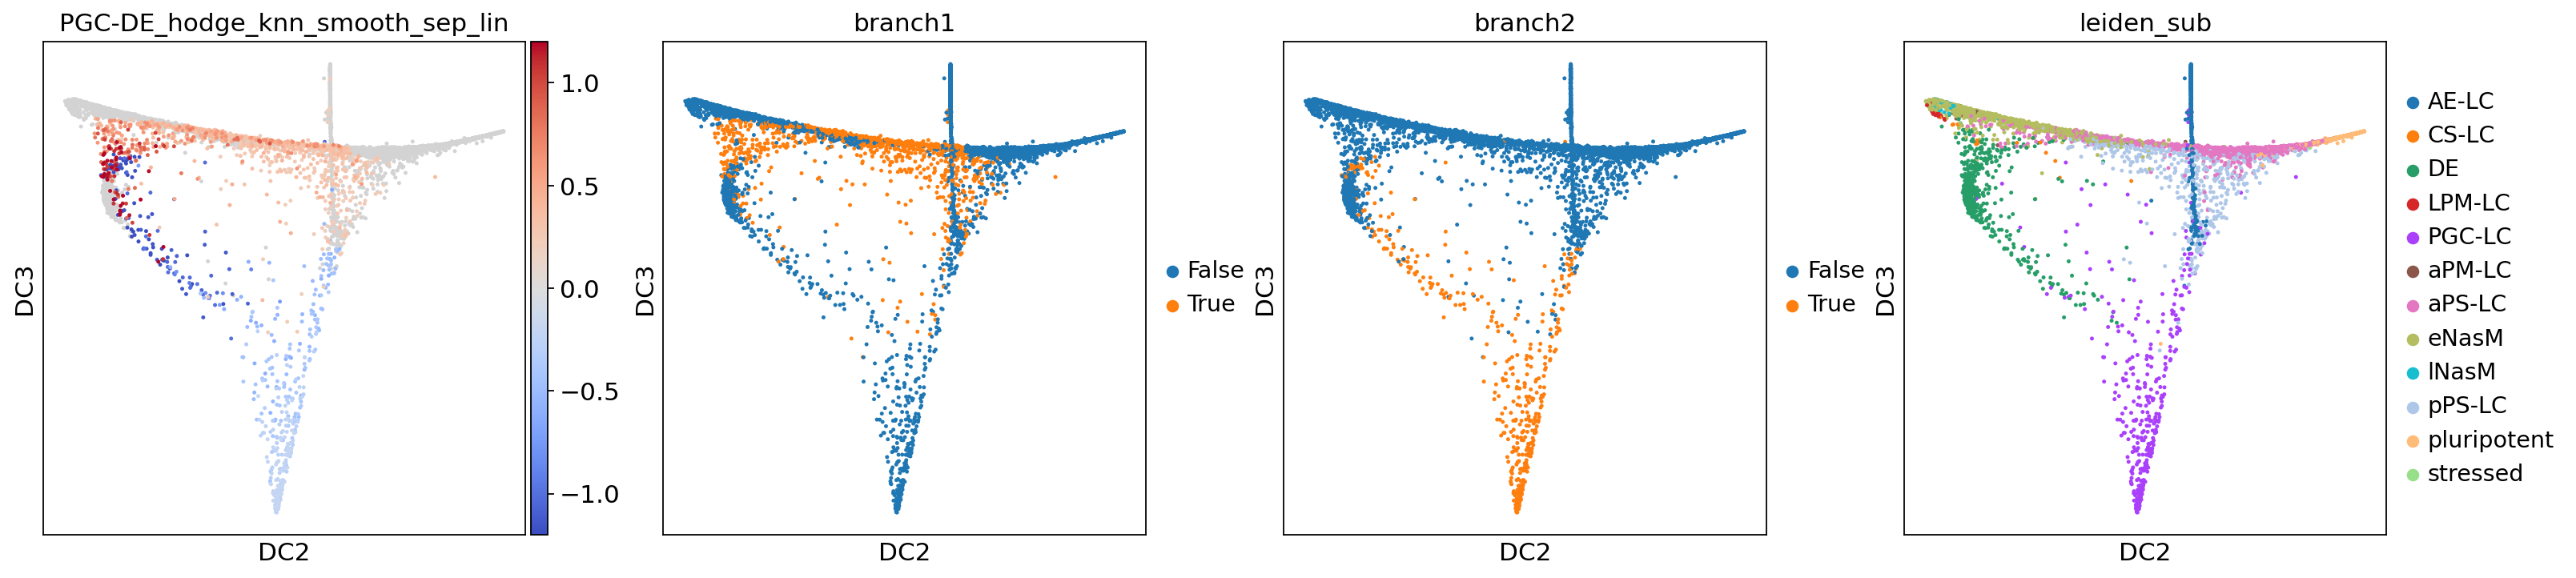

In [7]:
sc.pl.diffmap(
    adata,
    color=["PGC-DE_hodge_knn_smooth_sep_lin", "branch1", "branch2", "leiden_sub"],
    s=20,
    show=False,
    components=["2,3"],
    # vmin=-0.004,
    # vmax=0.004,
    cmap="coolwarm",
)

# HVG output

In [8]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1_hvg/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords
f.close()

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

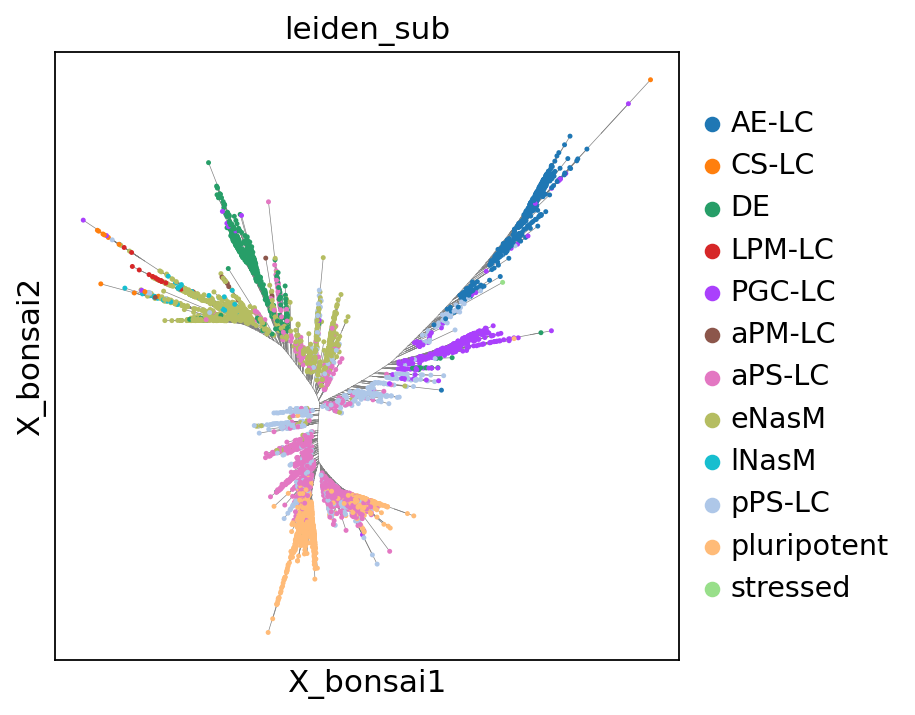

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

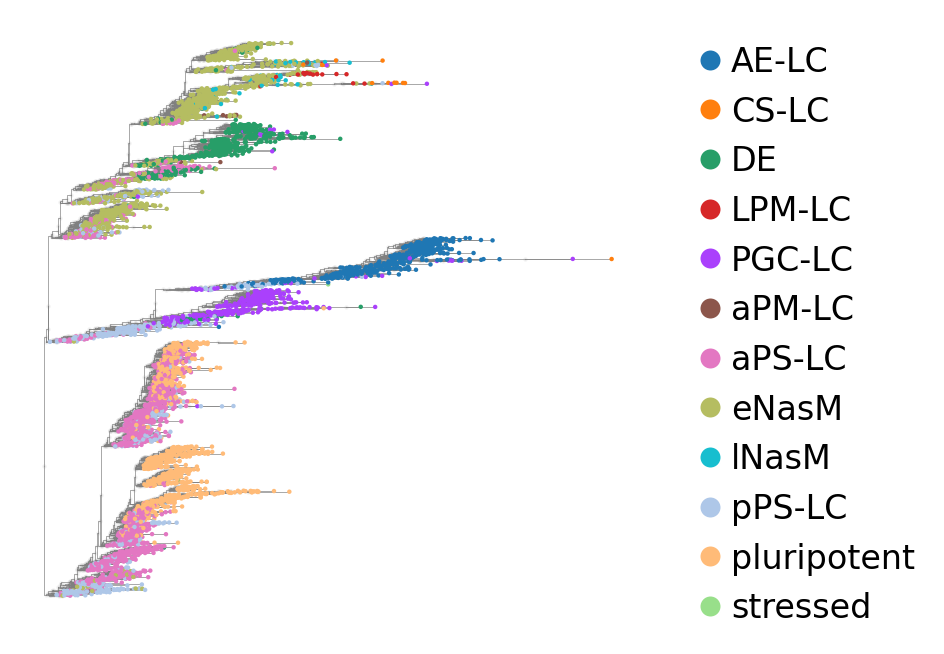

In [10]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1_hvg/bonsai_vis_data.hdf", "r")
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
f.close()

In [11]:
from my_tree_layout import Layout_Tree

node_id_to_vert_ind = {}
with open("./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai/vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

with open("./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai/tree.nwk") as f:
    nwk_str = f.read().strip()

ly_tree = Layout_Tree()
ly_tree.from_newick(nwk_str, node_id_to_vert_ind=node_id_to_vert_ind)
ly_tree.reset_root(node_id_to_vert_ind["internal_906"])
ly_tree.equalAngle()
coords = ly_tree.coords.copy()

(np.float64(-1.045),
 np.float64(1.0450000000000002),
 np.float64(-1.045),
 np.float64(1.045))

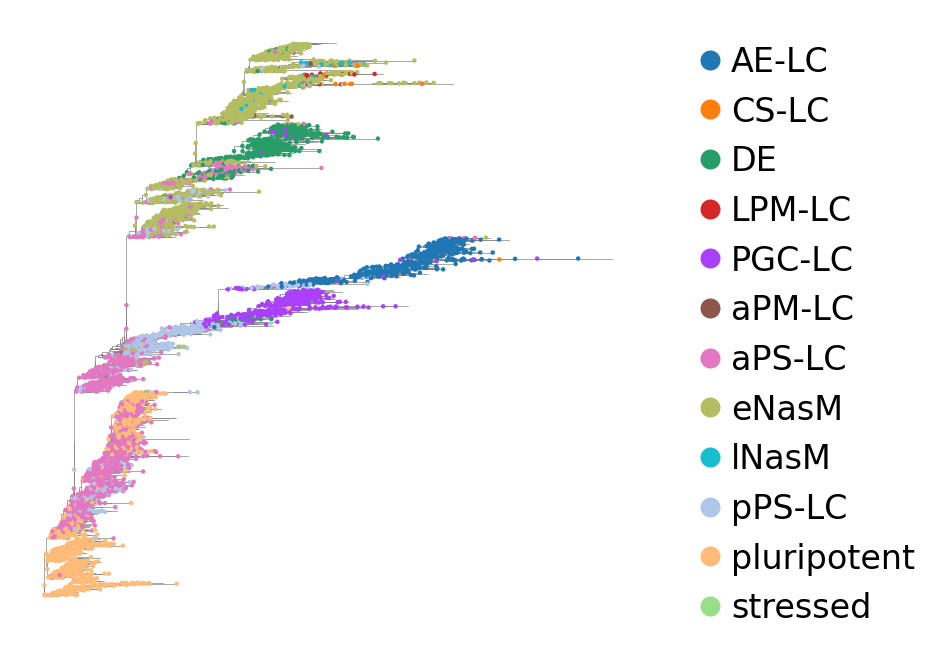

In [12]:
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [13]:
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")

from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

annotation_dict = adata.obs["leiden_sub"].to_dict()

with open("./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai/tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

03-31 14:29:51 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5515271657209468.
03-31 14:29:51 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.628842271477425.
03-31 14:29:51 mp_print INFO 
After making 7 clusters, norm. mutual information doesn't significantly increase. Stopping here.
03-31 14:29:51 mp_print INFO Final annotation-based clustering did 7 moves, created 7 clusters, with a Normalized Mutual Information of 0.6508135327758374.
03-31 14:29:51 mp_print INFO Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

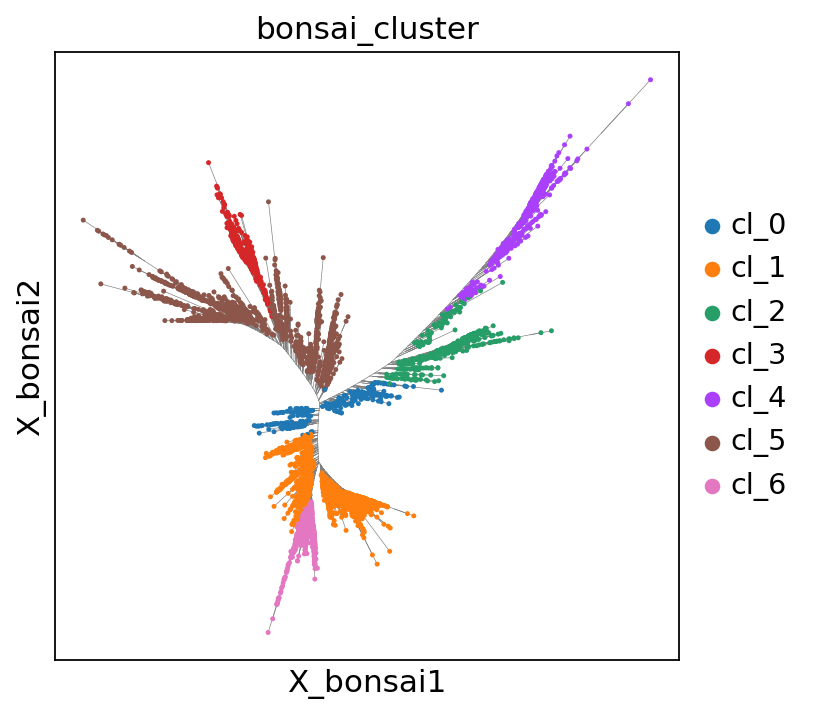

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

(np.float64(-1.045),
 np.float64(1.0450000000000002),
 np.float64(-1.045),
 np.float64(1.045))

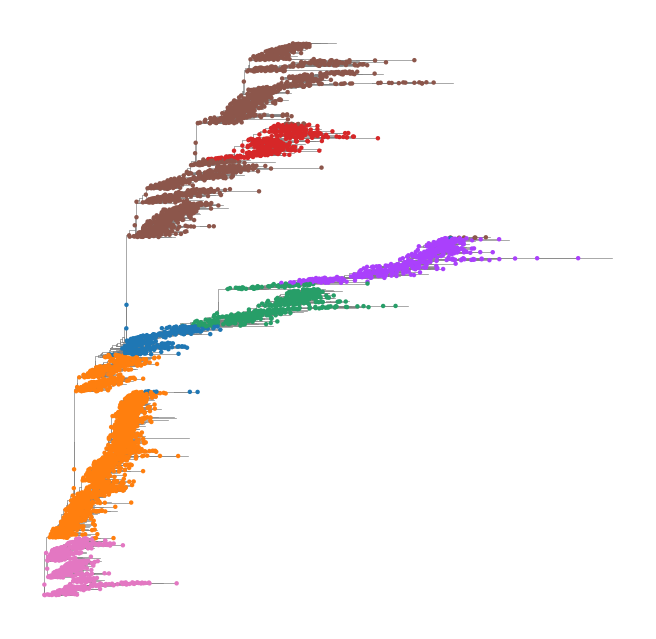

In [15]:
colors = adata.uns["bonsai_cluster_colors"]
categories = adata.obs["bonsai_cluster"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["bonsai_cluster"].map(cat_to_color).values

ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

2707


(np.float64(-1.045),
 np.float64(1.0450000000000002),
 np.float64(-1.045),
 np.float64(1.045))

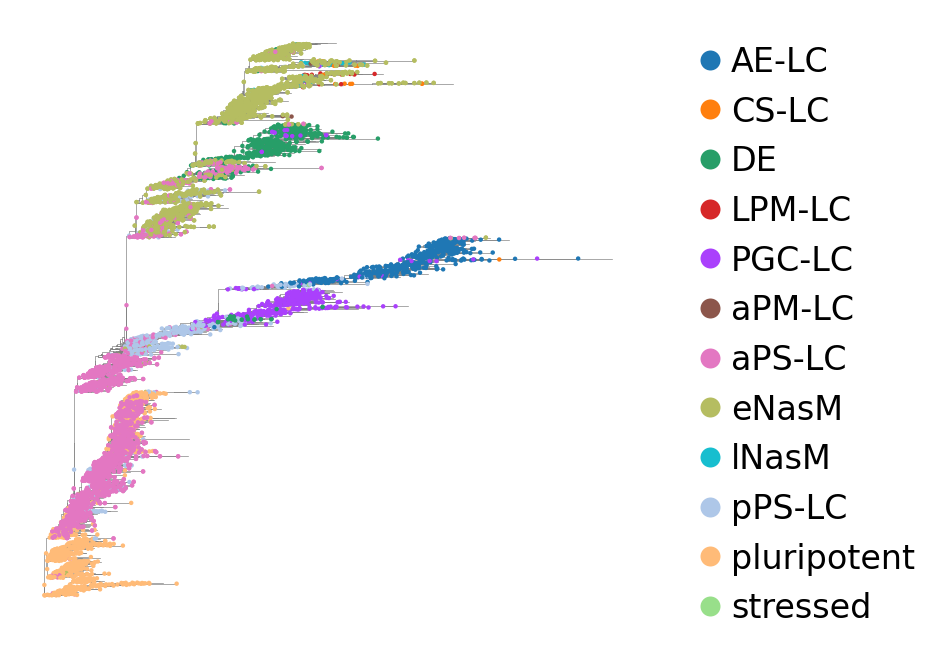

In [16]:
highlight_cells = np.concatenate(
    [
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "DE",
                adata.obs["bonsai_cluster"].str.contains("cl_2|cl_0|cl_4"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "PGC-LC",
                adata.obs["bonsai_cluster"].str.contains("cl_3|cl_5"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("eNasM|aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_5"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_1"),
            )
        )[0],
    ]
)
print(len(highlight_cells))

colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()
np.random.seed(1)
reorder_ind = np.random.permutation(cell_coords_d.shape[0])

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    cell_coords_d[reorder_ind, 0],
    cell_coords_d[reorder_ind, 1],
    s=1,
    c=cell_colors[reorder_ind],
    zorder=3,
)
ax.scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    s=1,
    c=cell_colors[highlight_cells],
    zorder=5,
)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [ ]:
import networkx as nx
from tqdm import tqdm

# distances to all des, get a matrix
# source_verts_bc = adata.obs.index[adata.obs["bonsai_cluster"] == "cl_3"].to_list()
# try all cells
source_verts_bc = adata.obs.index.to_list()
bonsai_dir = "./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai"
ltq_coords = np.load(f"{bonsai_dir}/posterior_ltqs_vertByGene.npy")
ltq_var_coords = np.load(f"{bonsai_dir}/posterior_ltqsVars_vertByGene.npy")
source_verts = [node_id_to_vert_ind[v] for v in source_verts_bc]

dist_matrix_tree_t = np.zeros((len(source_verts), len(cell_ids)))
dist_matrix_tree_e = np.zeros((len(source_verts), len(cell_ids)))
dist_matrix_straight = np.zeros((len(source_verts), len(cell_ids)))
dist_matrix_diffmap = np.zeros((len(source_verts), len(cell_ids)))

cell_vert_inds = [node_id_to_vert_ind[cid] for cid in cell_ids]

std_factor = 2
straight_dist_scale = 0.3
with open(f"{bonsai_dir}/edgeInfo.txt") as f:
    G = nx.Graph()
    for line in f:
        v1, v2, d = line.strip().split("\t")
        v1, v2 = int(v1), int(v2)
        std_child = np.sqrt(ltq_var_coords[v2])
        eucli_d = np.maximum(
            np.abs(ltq_coords[v1] - ltq_coords[v2]) - std_factor * std_child, 0.0
        )
        eucli = float(np.linalg.norm(eucli_d))
        G.add_edge(v1, v2, weight=np.sqrt(float(d)), weight_euclidean=eucli)
    cell_diffmap = adata[cell_ids].obsm["X_diffmap_original"][:, :]
    print(f"Total {len(source_verts)} cells")
    for i, (source_vert, source_vert_bc) in enumerate(
        tqdm(zip(source_verts, source_verts_bc))
    ):
        # diffusion distance
        source_diffmap = adata[source_vert_bc].obsm["X_diffmap_original"][:, :]
        cell_diffmap_dists = np.linalg.norm(cell_diffmap - source_diffmap, axis=1)
        dist_matrix_diffmap[i, :] = cell_diffmap_dists
        # tree distance
        _tree_t = nx.shortest_path_length(G, source=source_vert, weight="weight")
        dist_matrix_tree_t[i, :] = [_tree_t[cvid] for cvid in cell_vert_inds]
        # tree euclidean distance
        _tree_e = nx.shortest_path_length(
            G, source=source_vert, weight="weight_euclidean"
        )
        dist_matrix_tree_e[i, :] = [_tree_e[cvid] for cvid in cell_vert_inds]
        # straightline distance
        dist_to_source_straightline = (
            np.linalg.norm(
                np.maximum(
                    np.abs(ltq_coords[cell_vert_inds] - ltq_coords[source_vert])
                    - std_factor * ltq_var_coords[cell_vert_inds],
                    0,
                ),
                axis=1,
            )
            * straight_dist_scale
        )
        dist_matrix_straight[i, :] = dist_to_source_straightline


Total 5927 cells


3452it [04:02, 13.80it/s]

In [ ]:
# in case using all cells sort rows as well
# to make sense of all cell to all cell, order has to be done hierachically, such as order cluster by mean t or something first then order individual cells internally
# but say i see two cells have short distance, how can i tell if tree is wrong and implies a loop or one is the other's ancestor
# probably hard to say unless i know they diverged at some point
# but also it would be difficult to interpret result if cells are not clusered by actual cell types
order_row = True
order_by_cell_t = True
order_by_cluster_t = True
# add white list clusters i dont want to break, probably just merge ambient cells into major branch
white_list_cell_types = ["PGC-LC", "DE"]
cell_type_vec = adata.obs.loc[cell_ids, "leiden_sub"].copy()
cluster_vec = adata.obs.loc[cell_ids, "bonsai_cluster"].copy()
clusters = cluster_vec.cat.categories
for c in white_list_cell_types:
    ct_distrib = cluster_vec[cell_type_vec == c].value_counts()
    # get most occur branch
    most_occur_branch = ct_distrib.idxmax()
    cluster_vec[
        np.logical_and(cell_type_vec == c, cluster_vec != most_occur_branch)
    ] = most_occur_branch
# tree t to the oldest root reorder matrix columns
root_id = "internal_906"
_tree_t = nx.shortest_path_length(
    G, source=node_id_to_vert_ind[root_id], weight="weight"
)
dists_to_root = np.array([_tree_t[cvid] for cvid in cell_vert_inds])
dists_to_root_by_cluster = np.zeros(len(cell_ids))
if order_by_cluster_t:
    for c in clusters:
        dists_to_root_by_cluster[cluster_vec == c] = np.mean(
            dists_to_root[cluster_vec == c]
        )
reorder_ind = np.arange(len(cell_ids))
if order_by_cell_t and order_by_cluster_t:
    # last key is primary
    reorder_ind = np.lexsort((dists_to_root, dists_to_root_by_cluster))
elif order_by_cell_t:
    reorder_ind = np.argsort(dists_to_root)
elif order_by_cluster_t:
    reorder_ind = np.argsort(dists_to_root_by_cluster)
dist_matrix_tree_t_ordered = dist_matrix_tree_t[:, reorder_ind]
dist_matrix_tree_e_ordered = dist_matrix_tree_e[:, reorder_ind]
dist_matrix_straight_ordered = dist_matrix_straight[:, reorder_ind]
dist_matrix_diffmap_ordered = dist_matrix_diffmap[:, reorder_ind]
if order_row:
    dist_matrix_tree_t_ordered = dist_matrix_tree_t_ordered[reorder_ind, :]
    dist_matrix_tree_e_ordered = dist_matrix_tree_e_ordered[reorder_ind, :]
    dist_matrix_straight_ordered = dist_matrix_straight_ordered[reorder_ind, :]
    dist_matrix_diffmap_ordered = dist_matrix_diffmap_ordered[reorder_ind, :]

In [34]:
# compute cell compositions for columns
window_size = 30
adata.obs.loc[cell_ids, "leiden_sub"]
cell_types = adata.obs["leiden_sub"].cat.categories
# add a dummy cell type for unknown (make it 1 to just avoid division by zero)
cell_composition_matrix = np.zeros((len(cell_types) + 1, len(cell_ids)))
for i, cell_type in enumerate(cell_types):
    res = np.convolve(
        adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == cell_type,
        np.ones(window_size),
        mode="valid",
    )
    margin = int(np.ceil((cell_composition_matrix.shape[1] - res.shape[0]) / 2))
    # padd zeros
    res = np.pad(res, (margin, margin), mode="constant")
    cell_composition_matrix[i, :] = res[: cell_composition_matrix.shape[1]]
cell_composition_matrix[-1, :] = 1
# compute percentage
cell_composition_matrix = cell_composition_matrix / np.sum(
    cell_composition_matrix, axis=0
)

/tmp/ipykernel_413206/3092788862.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == cell_type,
/tmp/ipykernel_413206/3092788862.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == cell_type,
/tmp/ipykernel_413206/3092788862.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] 

In [ ]:
# do mean trend (does not seem to make sense, too many cells)
from scipy.ndimage import uniform_filter1d
from scipy.stats import trim_mean

pct_cut = 0.05
dist_tree_t_mean = trim_mean(
    dist_matrix_tree_t_ordered, axis=0, proportiontocut=pct_cut
)
dist_tree_e_mean = trim_mean(
    dist_matrix_tree_e_ordered, axis=0, proportiontocut=pct_cut
)
dist_straight_mean = trim_mean(
    dist_matrix_straight_ordered, axis=0, proportiontocut=pct_cut
)
dist_diffmap_mean = trim_mean(
    dist_matrix_diffmap_ordered, axis=0, proportiontocut=pct_cut
)

# also smooth a bit
window_size = 60
dist_tree_t_mean = uniform_filter1d(
    trim_mean(dist_matrix_tree_t_ordered, axis=0, proportiontocut=pct_cut),
    size=window_size * 10,
    mode="nearest",
)
dist_tree_e_mean = uniform_filter1d(
    trim_mean(dist_matrix_tree_e_ordered, axis=0, proportiontocut=pct_cut),
    size=window_size,
    mode="nearest",
)
dist_straight_mean = uniform_filter1d(
    trim_mean(dist_matrix_straight_ordered, axis=0, proportiontocut=pct_cut),
    size=window_size,
    mode="nearest",
)
dist_diffmap_mean = uniform_filter1d(
    trim_mean(dist_matrix_diffmap_ordered, axis=0, proportiontocut=pct_cut),
    size=window_size,
    mode="nearest",
)


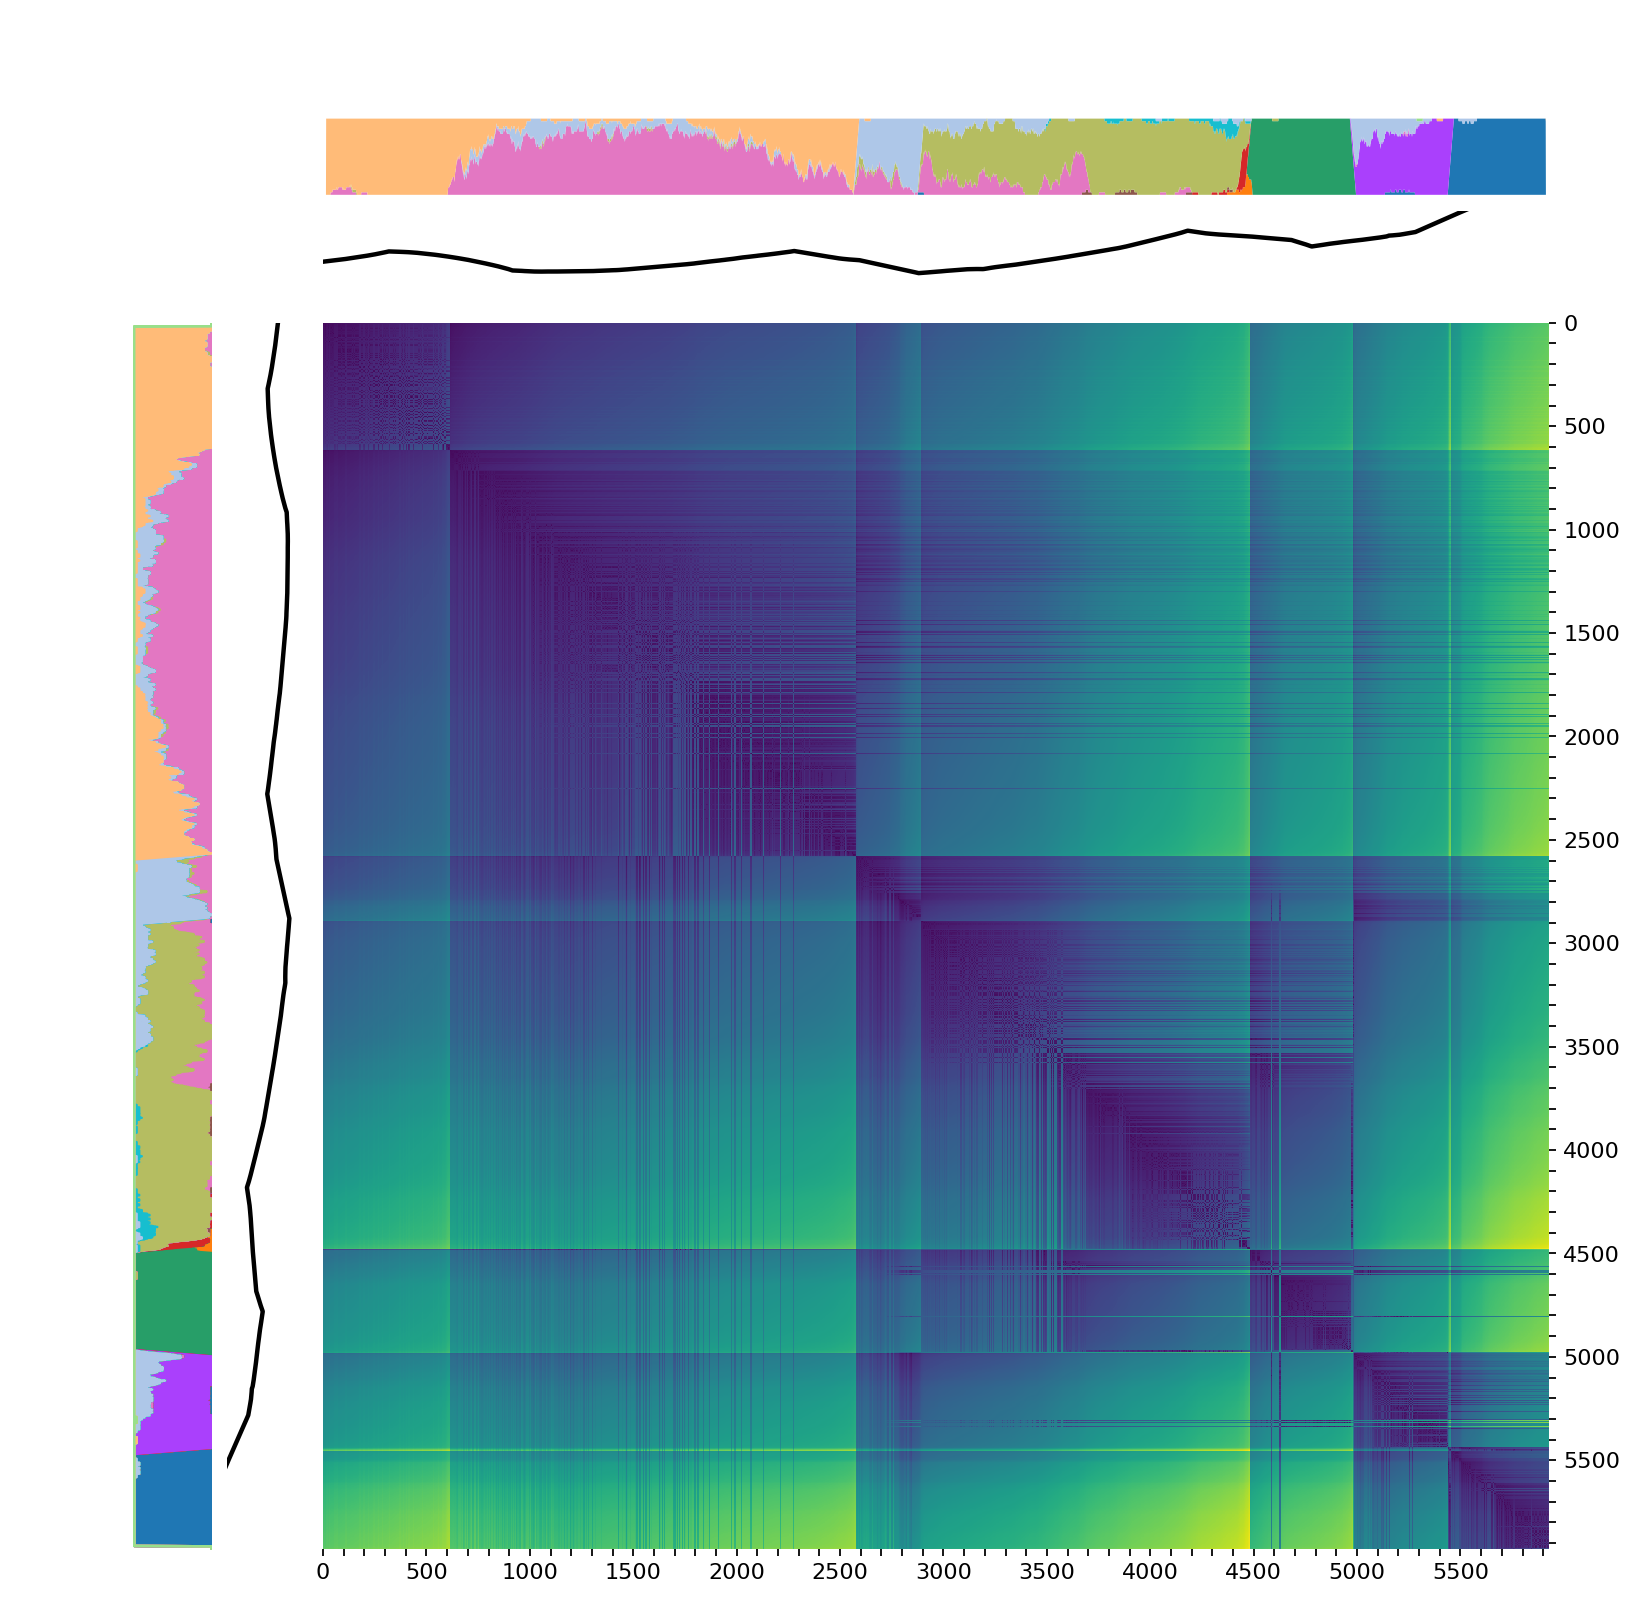

In [ ]:
import seaborn as sns

FONTSIZE = 10
matrices = [
    dist_matrix_tree_t_ordered,
    # dist_matrix_tree_e,
    # dist_matrix_straight,
    dist_matrix_diffmap_ordered,
]
titles = [
    "Tree (Edge Weight $d$)",
    # "Tree (Euclidean Edge)",
    # "Straightline Distance",
    "Diffusion Map Distance",
]
mean_distances = [
    dist_tree_t_mean,
    # dist_tree_e_mean,
    # dist_straight_mean,
    dist_diffmap_mean,
]
titles = [
    "Tree (Edge Weight $d$)",
    # "Tree (Euclidean Edge)",
    # "Straightline Distance",
    "Diffusion Map Distance",
]
min_max_scale = [
    (0, 1),
    # (0, 20),
    # (0, 20),
    (0, 1),
]
ylims = [
    (0.3, 0.8),
    # (0, 20),
    # (0, 20),
    (0.5, 0.7),
]
x_offset = [
    0,
    # -10,
    # -10,
    0,
]

# distance matrix and cell composition
for mat, mean_dist, title, (min_val, max_val), ylim, x_off in zip(
    matrices, mean_distances, titles, min_max_scale, ylims, x_offset
):
    g = sns.clustermap(
        mat,
        cmap="viridis",
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
    )
    ax_hm = g.ax_heatmap
    g.cax.set_visible(False)
    pos = ax_hm.get_position()

    n = mat.shape[1]
    n_rows = mat.shape[0]
    x = np.arange(n) + x_off
    y = np.arange(n_rows)

    # --- ticks on heatmap ---
    tick_x = np.arange(0, n, 100)
    tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
    ax_hm.set_xticks(tick_x)
    ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="x", which="major", length=3, direction="out")
    ax_hm.grid(False)

    tick_y = np.arange(0, n_rows, 100)
    tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
    ax_hm.set_yticks(tick_y)
    ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="y", which="major", length=3, direction="out")

    # # --- mean trend (normalized) ---
    # mean_norm = np.maximum(
    #     (mean_dist / np.max(mean_dist) - min_val) / (max_val - min_val),
    #     0,
    # )

    # # --- top: mean trend ---
    # ax_mean_top = g.fig.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.05])
    # ax_mean_top.plot(x, mean_norm, c="black", lw=2)
    # ax_mean_top.set_xlim(ax_hm.get_xlim())
    # ax_mean_top.set_ylim(ylim)
    # ax_mean_top.axis("off")

    # --- top: cell composition ---
    ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.02 + 0.01, pos.width, 0.05])
    ax_top.stackplot(
        x, cell_composition_matrix[:-1, :], labels=cell_types, colors=colors
    )
    ax_top.set_xlim(ax_hm.get_xlim())
    ax_top.axis("off")

    # # --- left: mean trend ---
    # ax_mean_left = g.fig.add_axes([pos.x0 - 0.06, pos.y0, 0.05, pos.height])
    # ax_mean_left.plot(mean_norm, y, c="black", lw=2)
    # ax_mean_left.set_ylim(ax_hm.get_ylim())
    # ax_mean_left.set_xlim(ylim)
    # ax_mean_left.invert_xaxis()
    # ax_mean_left.axis("off")

    # --- left: cell composition ---
    ax_left = g.fig.add_axes([pos.x0 - 0.06 - 0.01, pos.y0, 0.05, pos.height])
    cumulative = np.cumsum(cell_composition_matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for i in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[i], color=colors[i])
        prev = cumulative[i]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_hm.get_ylim())
    ax_left.axis("off")

    plt.show()
    plt.close()
import gc

gc.collect()

In [ ]:
# pick interval
interval

In [ ]:
# repeat after removing mesoderm
mask_white = np.logical_and(
    adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == "PGC-LC",
    adata.obs.loc[cell_ids, "bonsai_cluster"][reorder_ind].str.contains("cl_3|cl_5"),
)
mask_keep = np.logical_or(
    ~adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind].str.contains("NasM|DE"),
    mask_white,
)
mask_black = adata.obs.loc[cell_ids, "bonsai_cluster"][reorder_ind].str.contains("cl_5")
mask_keep = np.logical_and(mask_keep, ~mask_black)

# recompute cell composition after removing mesoderm
cell_composition_matrix_sub = np.zeros((len(cell_types) + 1, np.sum(mask_keep)))
for i, cell_type in enumerate(cell_types):
    res = np.convolve(
        adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind][mask_keep] == cell_type,
        np.ones(window_size),
        mode="valid",
    )
    margin = int(np.ceil((cell_composition_matrix_sub.shape[1] - res.shape[0]) / 2))
    res = np.pad(res, (margin, margin), mode="constant")
    cell_composition_matrix_sub[i, :] = res[: cell_composition_matrix_sub.shape[1]]
cell_composition_matrix_sub[-1, :] = 1
# compute percentage
cell_composition_matrix_sub = cell_composition_matrix_sub / np.sum(
    cell_composition_matrix_sub, axis=0
)
# distances can just use mask_keep to filter since cells are terminal nodes

/tmp/ipykernel_366499/3610657141.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == "PGC-LC",
/tmp/ipykernel_366499/3610657141.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs.loc[cell_ids, "bonsai_cluster"][reorder_ind].str.contains("cl_3|cl_5"),
/tmp/ipykernel_366499/3610657141.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ~adata.obs.loc[cell_ids, "leiden_su

In [428]:
from scipy.ndimage import uniform_filter1d
from scipy.stats import trim_mean

pct_cut = 0.05

# mean distance trend
dist_tree_t_mean = trim_mean(dist_matrix_tree_t, axis=0, proportiontocut=pct_cut)
dist_tree_e_mean = trim_mean(dist_matrix_tree_e, axis=0, proportiontocut=pct_cut)
dist_straight_mean = trim_mean(dist_matrix_straight, axis=0, proportiontocut=pct_cut)
dist_diffmap_mean = trim_mean(dist_matrix_diffmap, axis=0, proportiontocut=pct_cut)

window_size = 60

dist_tree_t_mean = uniform_filter1d(
    trim_mean(dist_matrix_tree_t, axis=0, proportiontocut=pct_cut),
    size=window_size * 10,
    mode="nearest",
)
dist_tree_e_mean = uniform_filter1d(
    trim_mean(dist_matrix_tree_e, axis=0, proportiontocut=pct_cut),
    size=window_size,
    mode="nearest",
)
dist_straight_mean = uniform_filter1d(
    trim_mean(dist_matrix_straight, axis=0, proportiontocut=pct_cut),
    size=window_size,
    mode="nearest",
)
dist_diffmap_mean = uniform_filter1d(
    trim_mean(dist_matrix_diffmap, axis=0, proportiontocut=pct_cut),
    size=window_size,
    mode="nearest",
)

# also smooth a bit
# window_size = 15
# margin = window_size // 2
# dist_tree_t_mean = np.pad(dist_tree_t_mean, (margin, margin), mode="constant")
# dist_tree_t_mean = np.convolve(
#     dist_tree_t_mean, np.ones(window_size) / window_size, mode="valid"
# )
# dist_tree_t_mean = dist_tree_t_mean[: dist_matrix_tree_t.shape[1]]
# dist_tree_e_mean = np.pad(dist_tree_e_mean, (margin, margin), mode="constant")
# dist_tree_e_mean = np.convolve(
#     dist_tree_e_mean, np.ones(window_size) / window_size, mode="valid"
# )
# dist_tree_e_mean = dist_tree_e_mean[: dist_matrix_tree_e.shape[1]]
# dist_straight_mean = np.pad(dist_straight_mean, (margin, margin), mode="constant")
# dist_straight_mean = np.convolve(
#     dist_straight_mean, np.ones(window_size) / window_size, mode="valid"
# )
# dist_straight_mean = dist_straight_mean[: dist_matrix_straight.shape[1]]
# dist_diffmap_mean = np.pad(dist_diffmap_mean, (margin, margin), mode="constant")
# dist_diffmap_mean = np.convolve(
#     dist_diffmap_mean, np.ones(window_size) / window_size, mode="valid"
# )
# dist_diffmap_mean = dist_diffmap_mean[: dist_matrix_diffmap.shape[1]]


In [429]:
# # mean distance trend
# dist_tree_t_mean = np.mean(dist_matrix_tree_t, axis=0)
# dist_tree_e_mean = np.mean(dist_matrix_tree_e, axis=0)
# dist_straight_mean = np.mean(dist_matrix_straight, axis=0)
# dist_diffmap_mean = np.mean(dist_matrix_diffmap, axis=0)

# window_size = 15


# def smooth_ma(y: np.ndarray, w: int) -> np.ndarray:
#     return pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()


# dist_tree_t_mean = smooth_ma(dist_tree_t_mean, window_size)
# dist_tree_e_mean = smooth_ma(dist_tree_e_mean, window_size)
# dist_straight_mean = smooth_ma(dist_straight_mean, window_size)
# dist_diffmap_mean = smooth_ma(dist_diffmap_mean, window_size)


/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


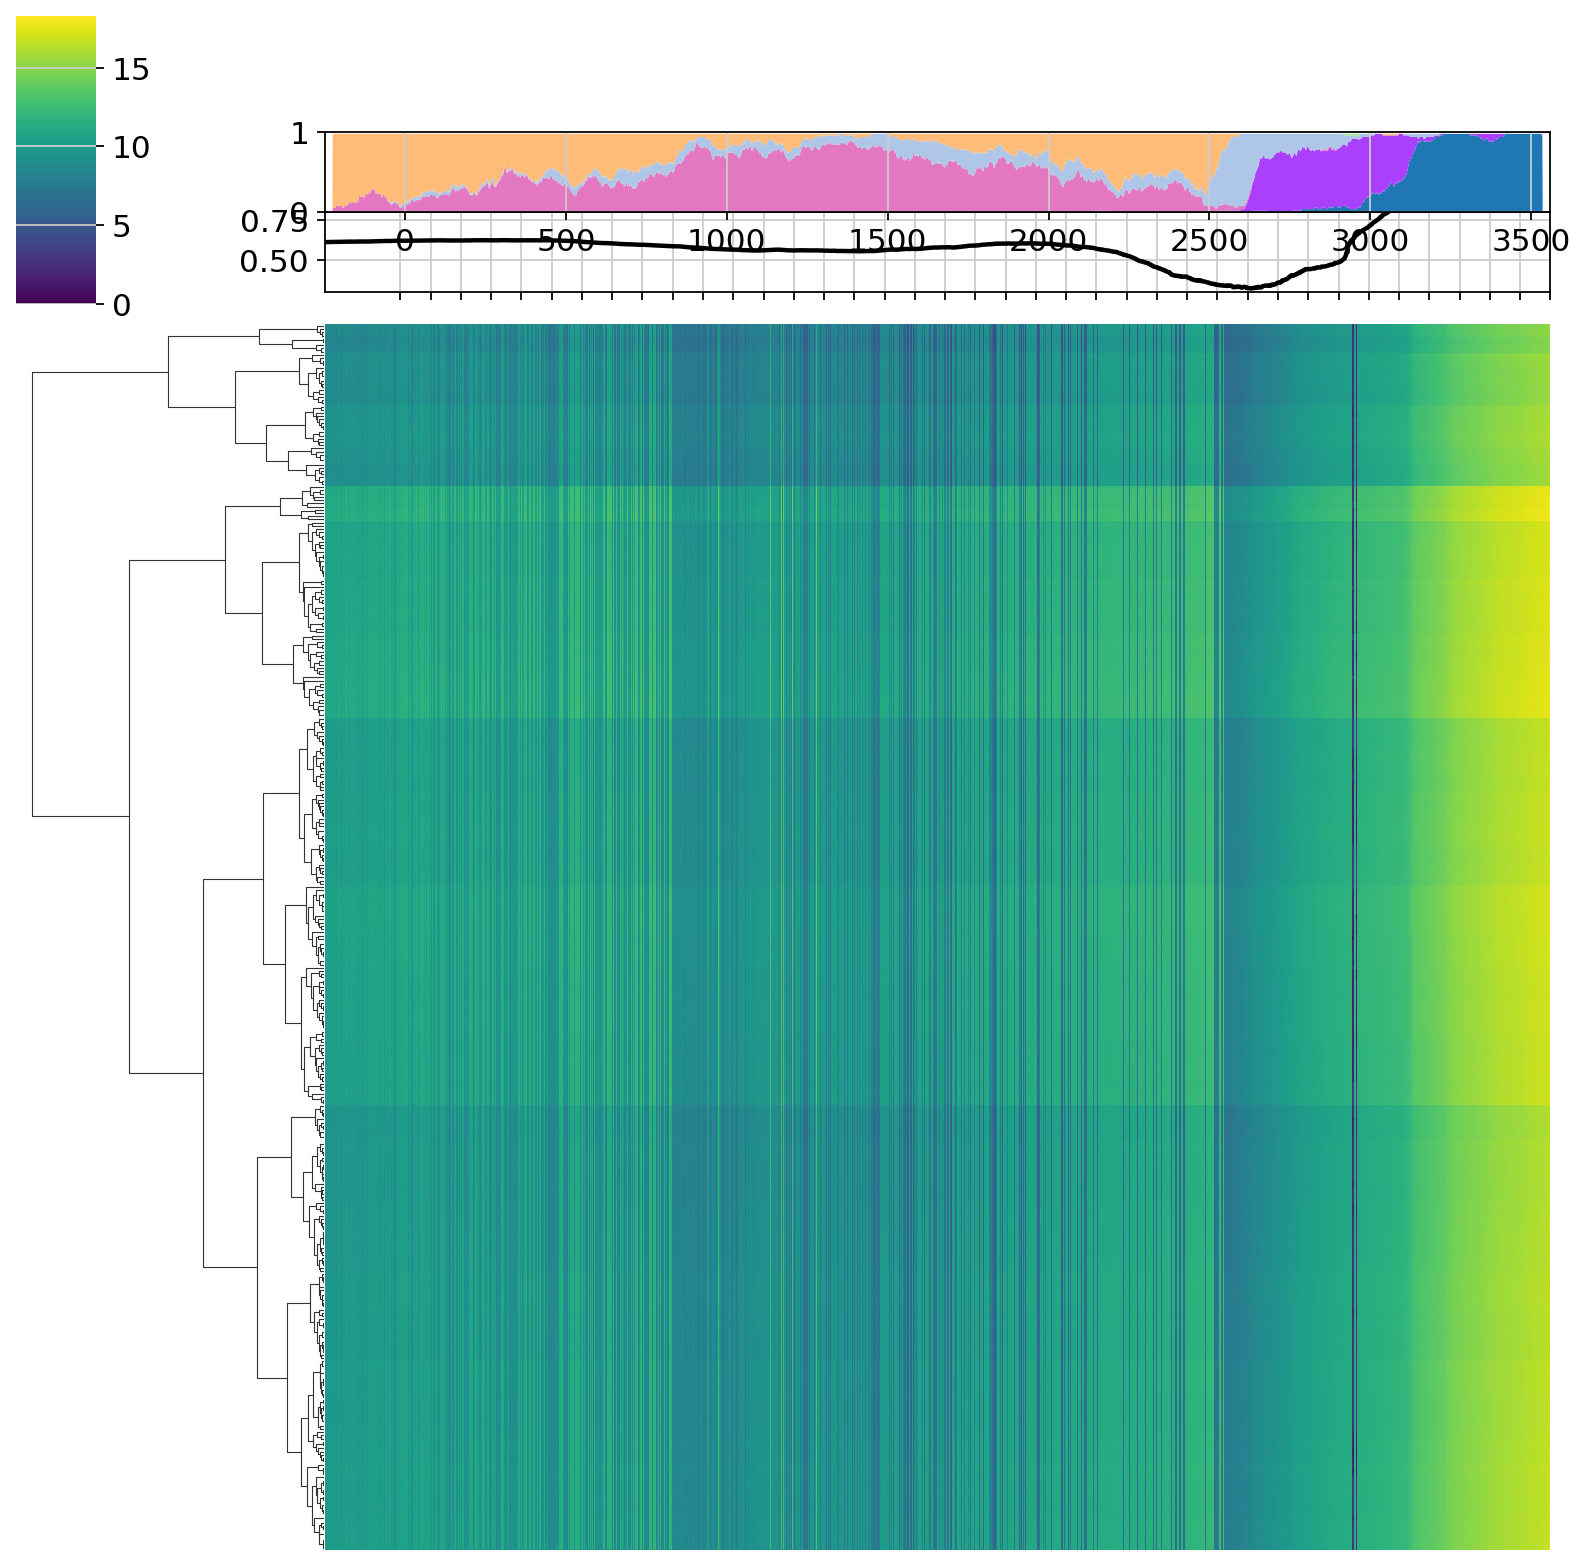

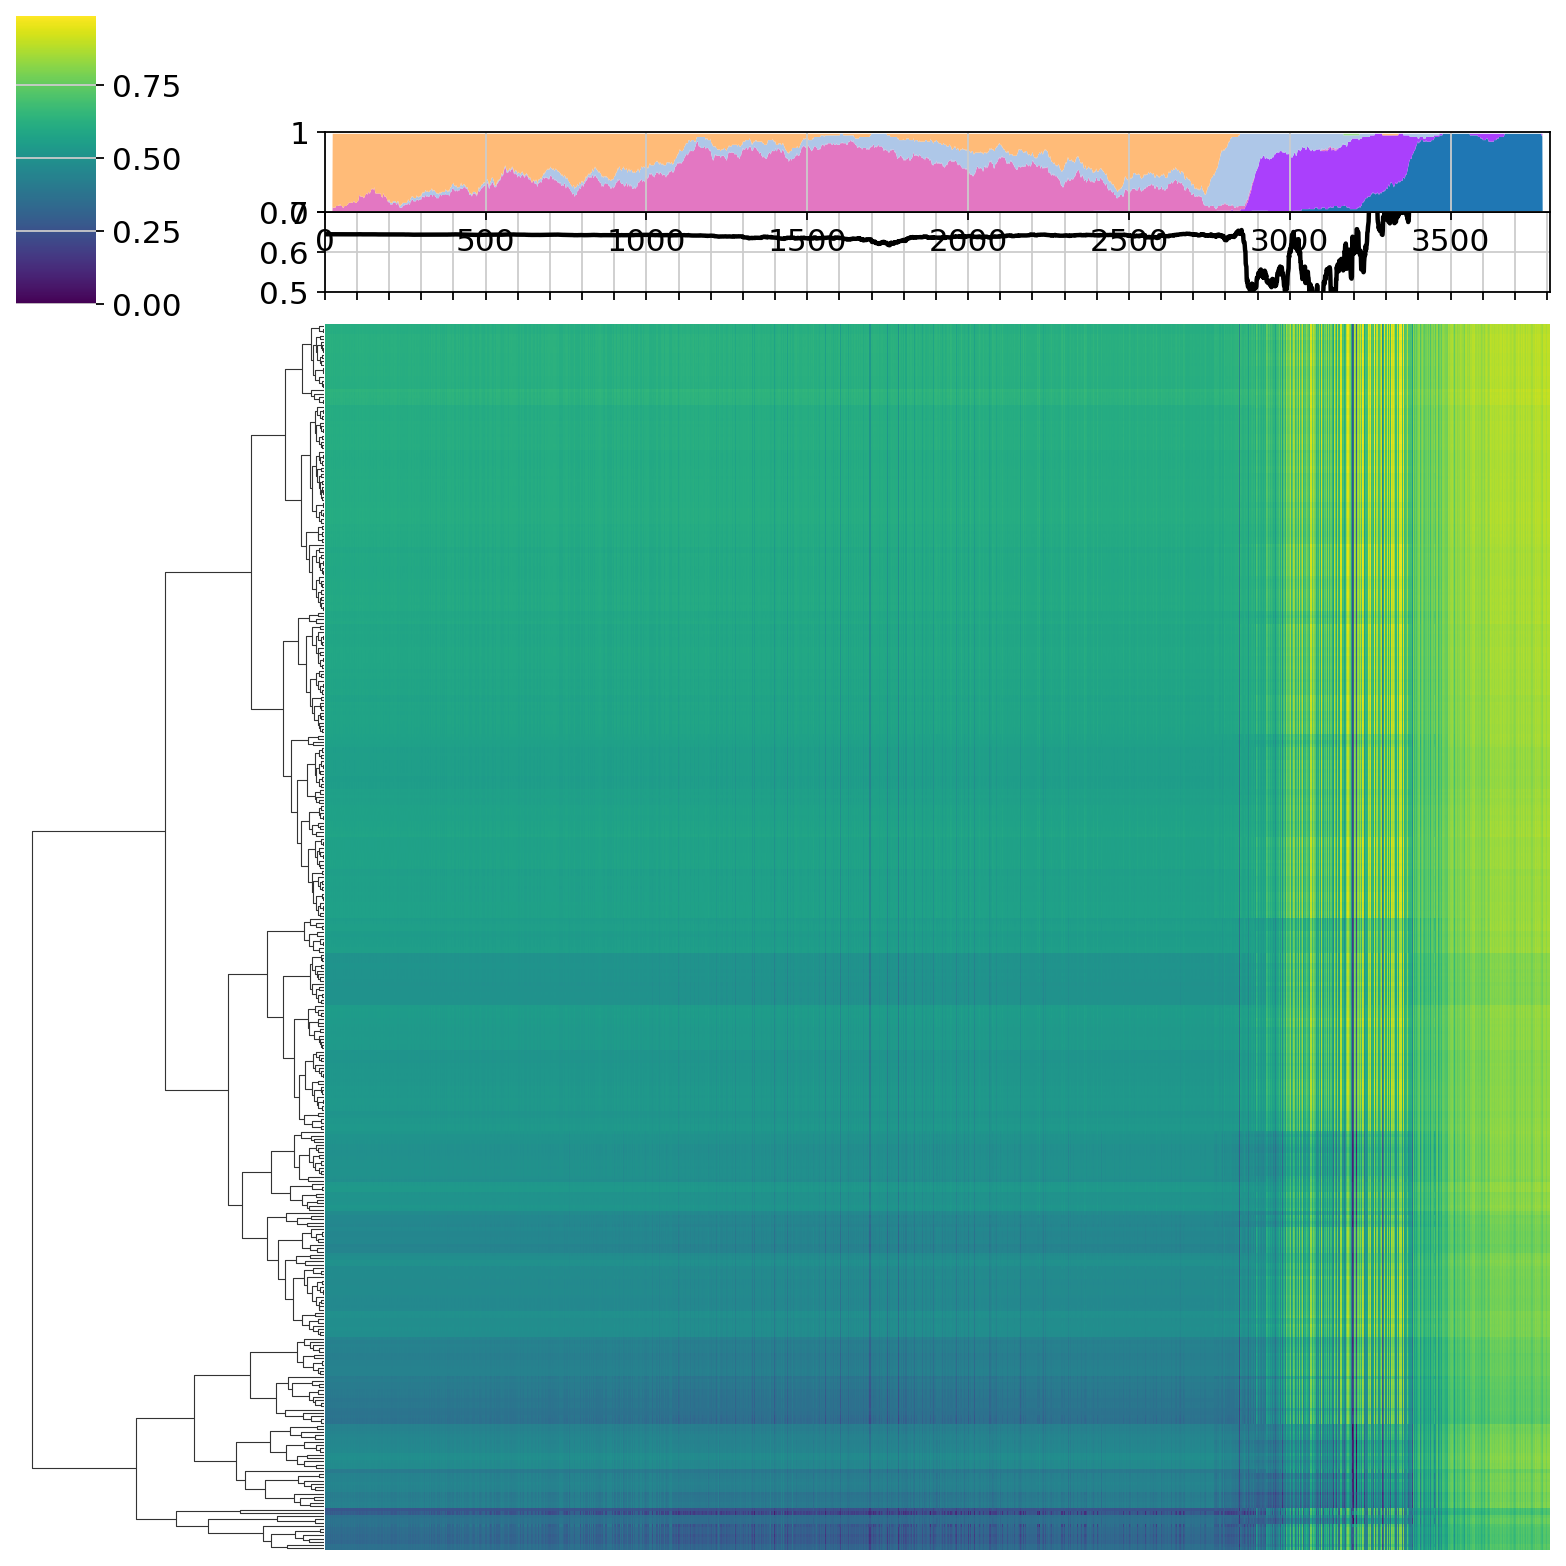

In [ ]:
import seaborn as sns
from matplotlib.colors import PowerNorm

matrices = [
    dist_matrix_tree_t,
    # dist_matrix_tree_e,
    # dist_matrix_straight,
    dist_matrix_diffmap,
]
mean_distances = [
    dist_tree_t_mean,
    # dist_tree_e_mean,
    # dist_straight_mean,
    dist_diffmap_mean,
]
titles = [
    "Tree (Edge Weight $d$)",
    # "Tree (Euclidean Edge)",
    # "Straightline Distance",
    "Diffusion Map Distance",
]
min_max_scale = [
    (0, 1),
    # (0, 20),
    # (0, 20),
    (0, 1),
]
ylims = [
    (0.3, 0.8),
    # (0, 20),
    # (0, 20),
    (0.5, 0.7),
]
x_offset = [
    -250,
    # -10,
    # -10,
    0,
]
interval = (2920, 2980)
# distance matrix and cell composition
for (mean_dist, mat), title, (min_val, max_val), ylim, x_off in zip(
    zip(mean_distances, matrices), titles, min_max_scale, ylims, x_offset
):
    g = sns.clustermap(
        mat[:, mask_keep],
        cmap="viridis",
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=True,
        col_cluster=False,
        # norm=PowerNorm(gamma=1.5),
    )
    ax_hm = g.ax_heatmap
    pos = ax_hm.get_position()
    ax_mean_trend = g.fig.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.05])
    ax_cell_composition = g.fig.add_axes(
        [pos.x0, pos.y1 + 0.02 + 0.05, pos.width, 0.05]
    )
    n = mat[:, mask_keep].shape[1]
    x = np.arange(n) + x_off
    ax_mean_trend.plot(
        x,
        np.maximum(
            (mean_dist[mask_keep] / np.max(mean_dist[mask_keep]) - min_val)
            / (max_val - min_val),
            0,
        ),
        c="black",
        lw=2,
    )
    ax_cell_composition.stackplot(
        x, cell_composition_matrix_sub[:-1, :], labels=cell_types, colors=colors
    )
    xlim = list(ax_hm.get_xlim())
    xlim[0] += x_off
    xlim[1] += x_off
    ax_mean_trend.set_xlim(xlim)
    ax_cell_composition.set_xlim(xlim)
    ax_mean_trend.set_xticks(np.arange(0, n, 100), labels=[])
    ax_cell_composition.set_ylim(0, 1)
    ax_mean_trend.set_ylim(ylim)

/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


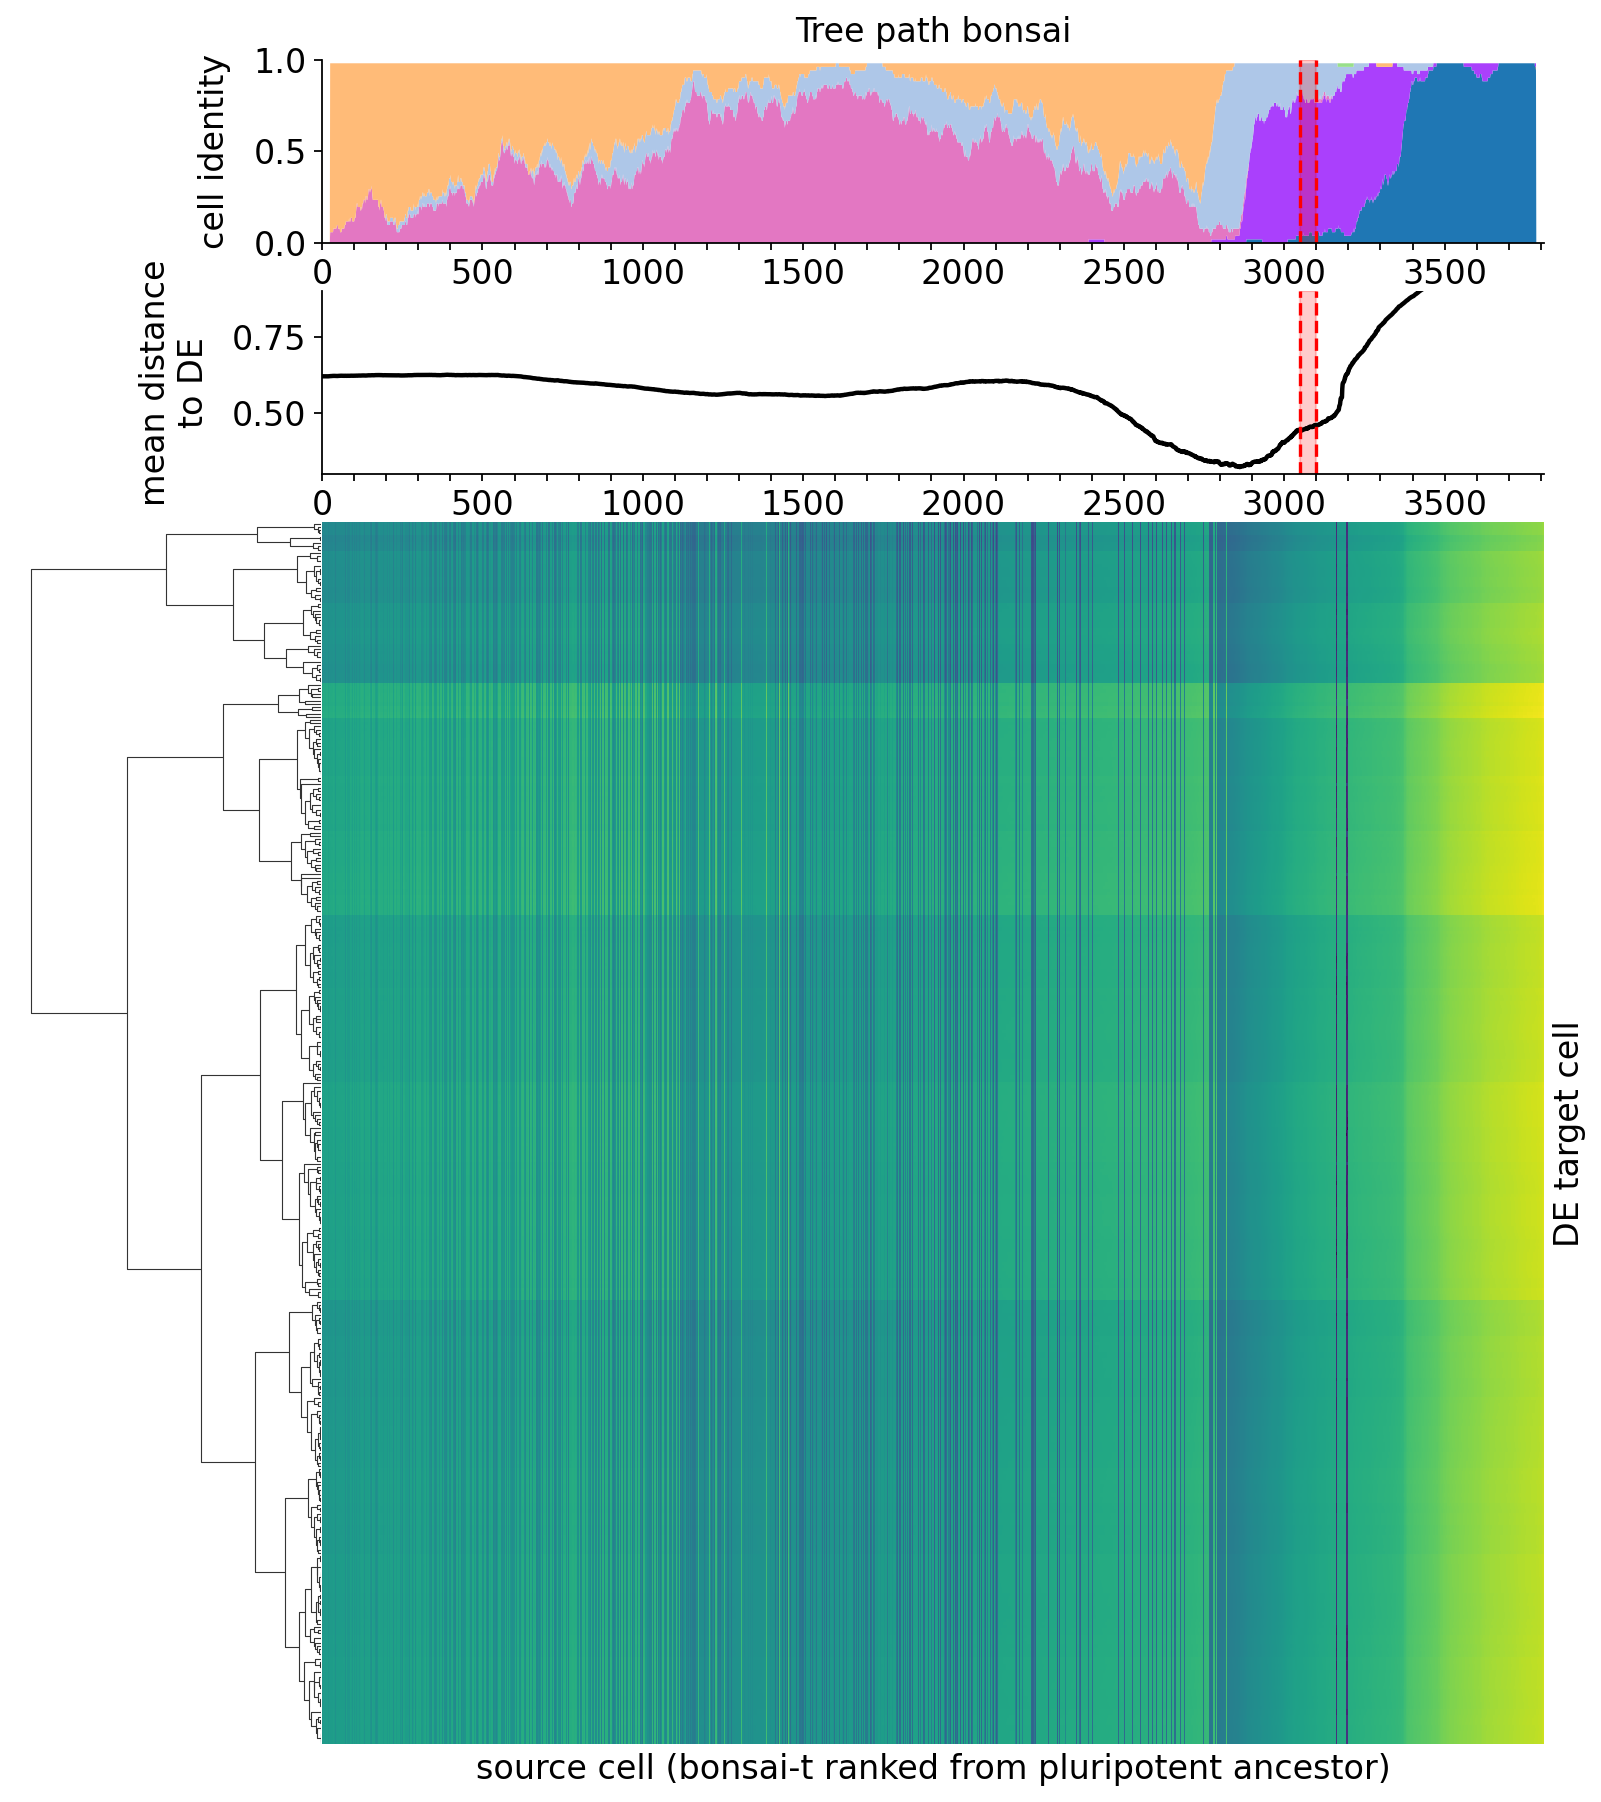

/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


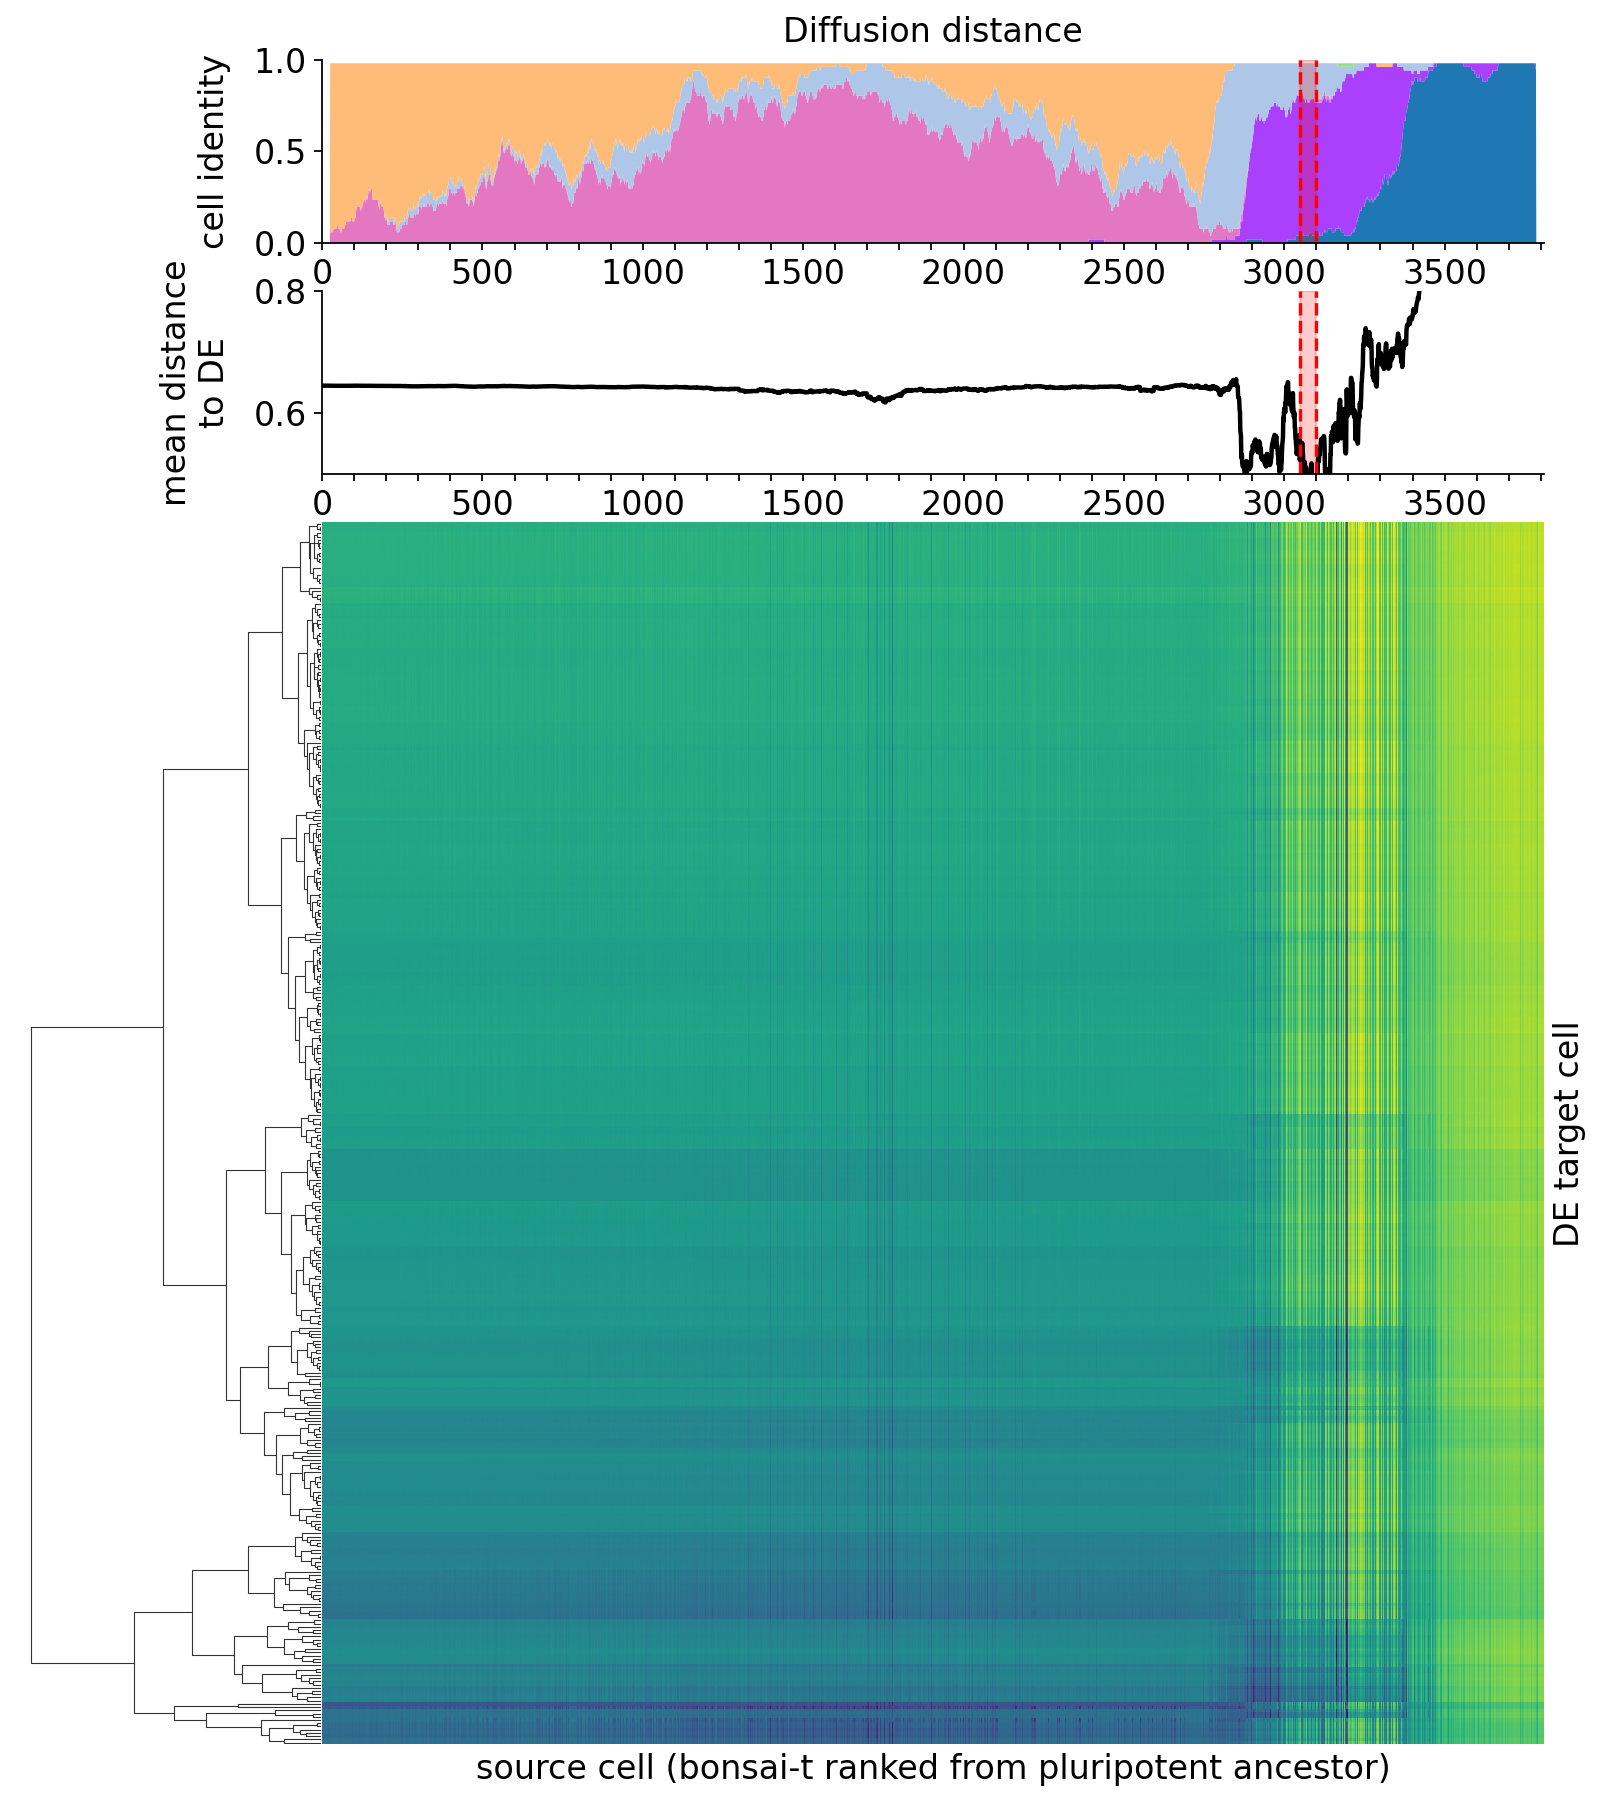

In [476]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

FONTSIZE = 15
plt.rcParams.update(
    {
        "font.size": FONTSIZE,
        "axes.titlesize": FONTSIZE,
        "axes.labelsize": FONTSIZE,
        "xtick.labelsize": FONTSIZE,
        "ytick.labelsize": FONTSIZE,
    }
)

matrices = [
    dist_matrix_tree_t,
    dist_matrix_diffmap,
]
mean_distances = [
    dist_tree_t_mean,
    dist_diffmap_mean,
]
titles = [
    "Tree path bonsai",
    "Diffusion distance",
]
min_max_scale = [
    (0, 1),
    (0, 1),
]
ylims = [
    (0.3, 0.9),
    (0.5, 0.8),
]
x_offset = [
    -200,
    0,
]
interval = (3050, 3100)

for (mean_dist, mat), title, (min_val, max_val), ylim, x_off in zip(
    zip(mean_distances, matrices), titles, min_max_scale, ylims, x_offset
):
    g = sns.clustermap(
        mat[:, mask_keep],
        cmap="viridis",
        cbar=False,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=True,
        col_cluster=False,
    )

    ax_hm = g.ax_heatmap
    pos = ax_hm.get_position()

    trace_h = pos.height * 0.15
    spacing = 0.03

    ax_mean_trend = g.fig.add_axes([pos.x0, pos.y1 + spacing, pos.width, trace_h])
    ax_cell_composition = g.fig.add_axes(
        [pos.x0, pos.y1 + spacing + trace_h + spacing, pos.width, trace_h]
    )

    n = mat[:, mask_keep].shape[1]
    x = np.arange(n)
    x_shifted = x + x_off  # only for mean trend data

    # --- mean distance trace (shifted by x_off) ---
    ax_mean_trend.plot(
        x_shifted,
        np.maximum(
            (mean_dist[mask_keep] / np.max(mean_dist[mask_keep]) - min_val)
            / (max_val - min_val),
            0,
        ),
        c="black",
        lw=2,
    )

    # --- cell composition trace (no shift) ---
    ax_cell_composition.stackplot(
        x, cell_composition_matrix_sub[:-1, :], labels=cell_types, colors=colors
    )

    # --- set xlims (same as heatmap, no shift) ---
    xlim = list(ax_hm.get_xlim())
    ax_mean_trend.set_xlim(xlim)
    ax_cell_composition.set_xlim(xlim)

    # --- consistent ticks ---
    tick_positions = np.arange(0, n, 100)
    tick_labels_empty = [str(int(t)) if t % 500 == 0 else "" for t in tick_positions]

    ax_mean_trend.set_xticks(tick_positions)
    ax_mean_trend.set_xticklabels(tick_labels_empty)
    ax_mean_trend.tick_params(axis="x", which="major", length=3, direction="out")

    ax_cell_composition.set_xticks(tick_positions)
    ax_cell_composition.set_xticklabels(tick_labels_empty)
    ax_cell_composition.tick_params(axis="x", which="major", length=3, direction="out")

    # --- y limits ---
    ax_cell_composition.set_ylim(0, 1)
    ax_mean_trend.set_ylim(ylim)

    # --- labels ---
    ax_hm.set_xlabel("source cell (bonsai-t ranked from pluripotent ancestor)")
    ax_hm.set_ylabel("DE target cell")
    ax_mean_trend.set_ylabel("mean distance\nto DE", rotation=90, labelpad=10)
    ax_cell_composition.set_ylabel("cell identity", rotation=90, labelpad=10)

    # --- title ---
    ax_cell_composition.set_title(title, pad=8)

    # --- highlight interval region (in unshifted coords) ---

    ax_mean_trend.axvspan(interval[0], interval[1], color="red", alpha=0.2)
    ax_mean_trend.axvline(interval[0], color="red", lw=1.5, linestyle="--")
    ax_mean_trend.axvline(interval[1], color="red", lw=1.5, linestyle="--")

    ax_cell_composition.axvspan(interval[0], interval[1], color="red", alpha=0.2)
    ax_cell_composition.axvline(interval[0], color="red", lw=1.5, linestyle="--")
    ax_cell_composition.axvline(interval[1], color="red", lw=1.5, linestyle="--")

    ax_mean_trend.grid(False)
    ax_cell_composition.grid(False)
    g.cax.set_visible(False)

    # --- clean up spines ---
    for ax in [ax_mean_trend, ax_cell_composition]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    plt.savefig(f"bonsai_distance_profile_{title}.png", dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_366499/3098767477.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  highlight_cells_interval = adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind][
/tmp/ipykernel_366499/3098767477.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  highlight_cells_interval2 = adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind][


2707


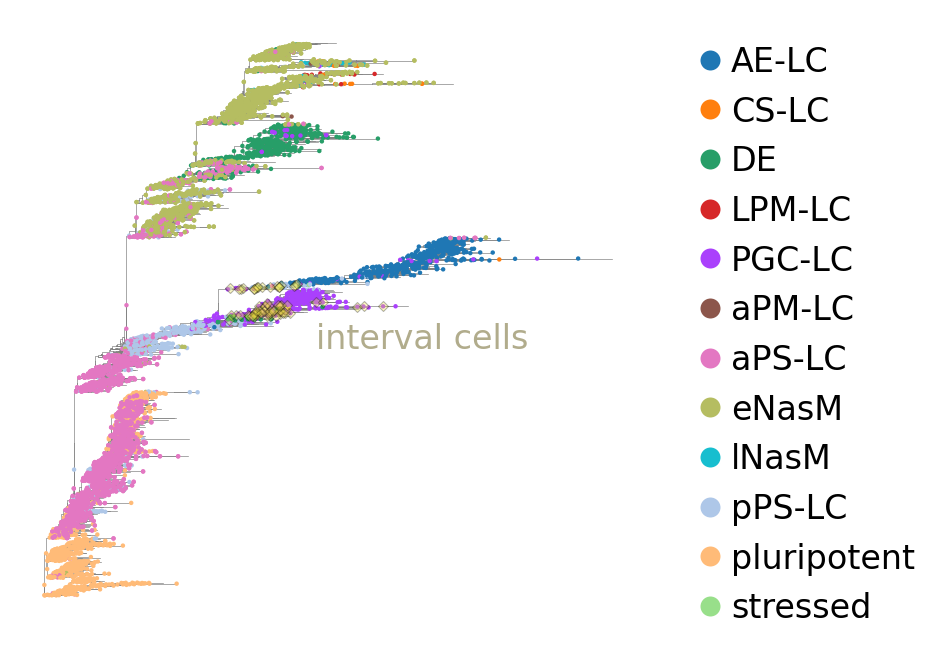

In [486]:
# check an interval of interest
interval2 = (2980, 3000)
highlight_cells_interval = adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind][
    mask_keep
][interval[0] : interval[1]]
highlight_cells_interval2 = adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind][
    mask_keep
][interval2[0] : interval2[1]]
highlight_cells_interval = highlight_cells_interval[
    highlight_cells_interval.str.contains("PGC|pPS|DE")
]
highlight_cells_interval2 = highlight_cells_interval2[
    highlight_cells_interval2.str.contains("PGC|pPS|DE")
]
highlight_cells_interval = [
    i
    for i, cid in enumerate(adata.obs.index)
    if cid in highlight_cells_interval or cid in highlight_cells_interval2
]

highlight_cells = np.concatenate(
    [
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "DE",
                adata.obs["bonsai_cluster"].str.contains("cl_2|cl_0|cl_4"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "PGC-LC",
                adata.obs["bonsai_cluster"].str.contains("cl_3|cl_5"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("eNasM|aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_5"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_1"),
            )
        )[0],
    ]
)
print(len(highlight_cells))

colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()
np.random.seed(1)
reorder_ind_rand = np.random.permutation(cell_coords_d.shape[0])

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    cell_coords_d[reorder_ind_rand, 0],
    cell_coords_d[reorder_ind_rand, 1],
    s=1,
    c=cell_colors[reorder_ind_rand],
    zorder=3,
)
ax.scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    s=1,
    c=cell_colors[highlight_cells],
    zorder=5,
)


# interval cells — red diamonds with black edge
ax.scatter(
    cell_coords_d[highlight_cells_interval, 0],
    cell_coords_d[highlight_cells_interval, 1],
    s=10,
    marker="D",
    facecolors="#fff244",
    edgecolors="black",
    linewidths=0.5,
    zorder=5,
    label="interval cells",
    alpha=0.3,
)

ax.set_aspect("auto")
ax.axis("off")
# annotate interval cells
interval_center_x = np.mean(cell_coords_d[highlight_cells_interval, 0])
interval_center_y = np.mean(cell_coords_d[highlight_cells_interval, 1])

ax.annotate(
    "interval cells",
    xy=(interval_center_x, interval_center_y),
    xytext=(
        interval_center_x + 0.15,
        interval_center_y - 0.15,
    ),  # adjust offset as needed
    fontsize=FONTSIZE,
    ha="left",
    # arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    color="#B1AC8C",
)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
plt.savefig("bonsai_qc_dendrogram_interval_cells.png", dpi=300, bbox_inches="tight")

In [17]:
# distances
import networkx as nx

bonsai_dir = "./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai"
ltq_coords = np.load(f"{bonsai_dir}/posterior_ltqs_vertByGene.npy")
ltq_var_coords = np.load(f"{bonsai_dir}/posterior_ltqsVars_vertByGene.npy")
source_vert = node_id_to_vert_ind["GTGCTGGTCGGTATGT-1_48h"]
std_factor = 2
G = nx.Graph()
with open(f"{bonsai_dir}/edgeInfo.txt") as f:
    for line in f:
        v1, v2, d = line.strip().split("\t")
        v1, v2 = int(v1), int(v2)
        std_child = np.sqrt(ltq_var_coords[v2])
        eucli_d = np.maximum(
            np.abs(ltq_coords[v1] - ltq_coords[v2]) - std_factor * std_child, 0.0
        )
        eucli = float(np.linalg.norm(eucli_d))
        G.add_edge(v1, v2, weight=np.sqrt(float(d)), weight_euclidean=eucli)

# straightline distance
straight_dist_scale = 0.3
dist_to_source_straightline = (
    np.linalg.norm(
        np.maximum(
            np.abs(ltq_coords - ltq_coords[source_vert]) - std_factor * ltq_var_coords,
            0,
        ),
        axis=1,
    )
    * straight_dist_scale
)

In [18]:
# recompute diffmap
if "X_diffmap" in adata.obsm:
    del adata.obsm["X_diffmap"]
adata.obsm["X_ltq"] = np.array(
    pd.read_csv(
        "./heemskerk_data/sanity_hvg/log_transcription_quotients_vmax.txt",
        sep="\t",
        index_col=0,
    )
).T
sc.pp.neighbors(adata, use_rep="X_ltq", n_neighbors=25, method="gauss")
sc.tl.diffmap(adata)
# diffusion distance
source_diffmap = adata["GTGCTGGTCGGTATGT-1_48h"].obsm["X_diffmap_original"][:, :]
cell_diffmap = adata[cell_ids].obsm["X_diffmap_original"][:, :]
cell_diffmap_dists = np.linalg.norm(cell_diffmap - source_diffmap, axis=1)

# Shortest path distances (= tree path distances since it's a tree)
source_vert = node_id_to_vert_ind["GTGCTGGTCGGTATGT-1_48h"]
bonsai_tree_t_dists = nx.shortest_path_length(G, source=source_vert, weight="weight")
bonsai_tree_e_dists = nx.shortest_path_length(
    G, source=source_vert, weight="weight_euclidean"
)

In [19]:
cell_dists_tree_t = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = bonsai_tree_t_dists.get(vert_idx, np.nan)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_tree_t[ci] = d
    else:
        cell_dists_tree_t[cell_idx] = d

cell_dists_tree_e = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = bonsai_tree_e_dists.get(vert_idx, np.nan)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_tree_e[ci] = d

cell_dists_straight = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = dist_to_source_straightline[vert_idx]
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_straight[ci] = d

cell_dists_diffmap = np.zeros(len(cell_ids))
for _, cell_idx in vert_to_cell.items():
    d = cell_diffmap_dists[cell_idx] if cell_idx else np.nan
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_diffmap[ci] = d
    else:
        cell_dists_diffmap[cell_idx] = d

/tmp/ipykernel_117772/3718620660.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cell_dists_diffmap[ci] = d


In [20]:
def draw_distance_icon(ax, kind="tree", loc=(0.85, 0.15), size=0.08):
    """
    Draw a small distance-type icon in axes-fraction coordinates.
    kind='tree': solid colored U with dots
    kind='straight': gray U with red direct line and dots
    """

    cx, cy = loc
    s = size
    half = s / 2

    # U shape: left arm up, bottom, right arm up
    u_x = [cx - half, cx - half, cx + half, cx + half]
    u_y = [cy + s, cy, cy, cy + s]

    if kind == "tree":
        ax.plot(
            u_x,
            u_y,
            color="royalblue",
            lw=2,
            solid_capstyle="round",
            transform=ax.transAxes,
            zorder=100,
            clip_on=False,
        )
        # dots at terminals
        ax.plot(
            [cx - half, cx + half],
            [cy + s, cy + s],
            "o",
            color="royalblue",
            ms=5,
            transform=ax.transAxes,
            zorder=101,
            clip_on=False,
        )
    elif kind == "straight":
        # gray U
        ax.plot(
            u_x,
            u_y,
            color="lightgray",
            lw=2,
            solid_capstyle="round",
            transform=ax.transAxes,
            zorder=100,
            clip_on=False,
        )
        # dots at terminals
        ax.plot(
            [cx - half, cx + half],
            [cy + s, cy + s],
            "o",
            color="red",
            ms=5,
            transform=ax.transAxes,
            zorder=101,
            clip_on=False,
        )
        # red direct line connecting the two dots
        ax.plot(
            [cx - half, cx + half],
            [cy + s, cy + s],
            "-",
            color="red",
            lw=2,
            transform=ax.transAxes,
            zorder=100,
            clip_on=False,
        )


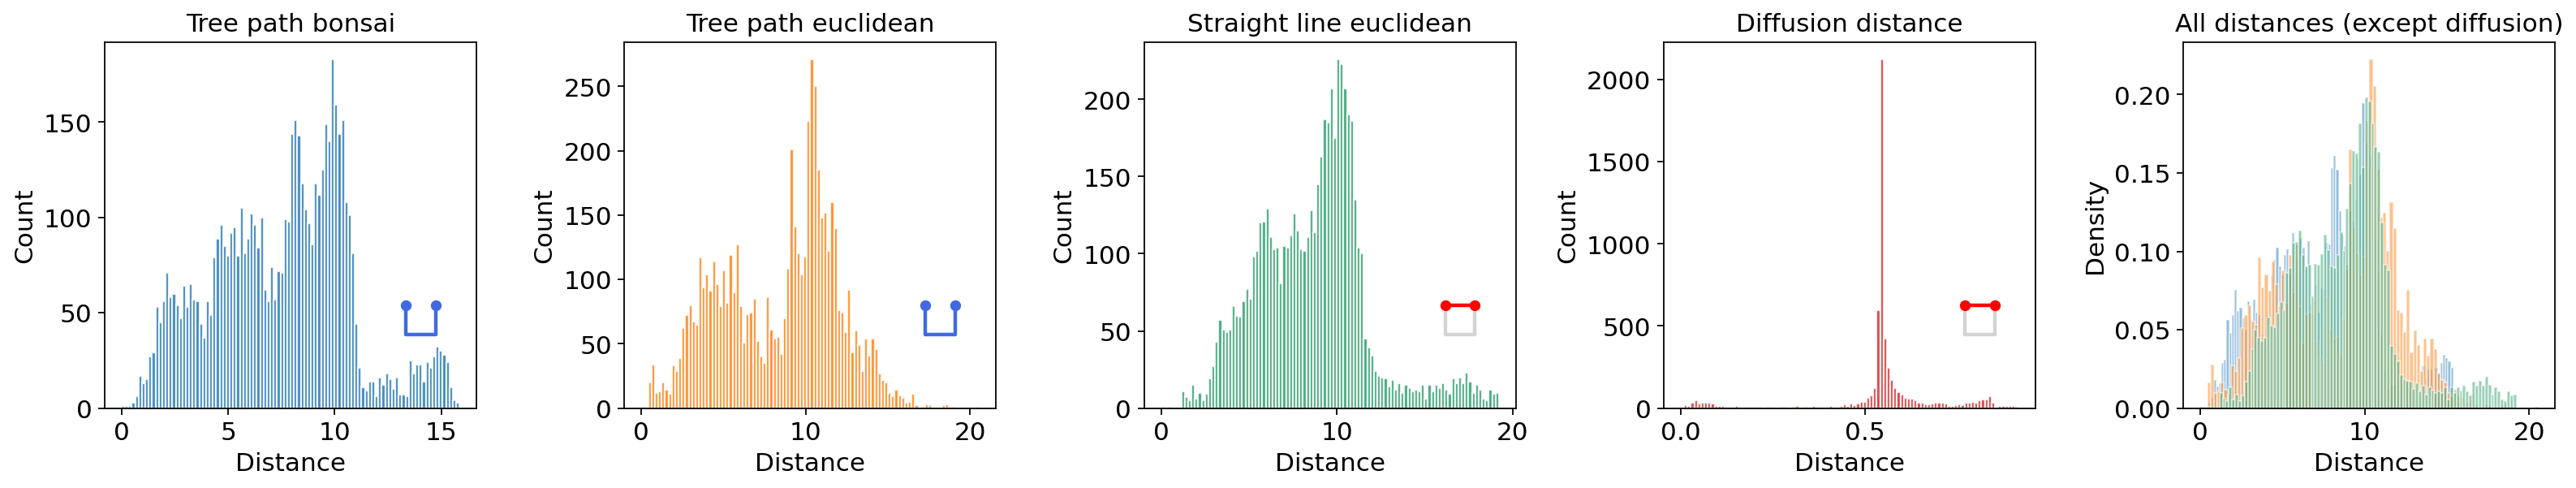

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].hist(cell_dists_tree_t, bins=100, color="C0", alpha=0.85, edgecolor="white")
axes[0].set_title("Tree path bonsai")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(cell_dists_tree_e, bins=100, color="C1", alpha=0.85, edgecolor="white")
axes[1].set_title("Tree path euclidean")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(cell_dists_straight, bins=100, color="C2", alpha=0.85, edgecolor="white")
axes[2].set_title("Straight line euclidean")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(cell_dists_diffmap, bins=100, color="C3", alpha=0.85, edgecolor="white")
axes[3].set_title("Diffusion distance")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Count")
axes[3].grid(False)

axes[4].hist(
    cell_dists_tree_t, bins=100, color="C0", alpha=0.5, edgecolor="white", density=True
)
axes[4].hist(
    cell_dists_tree_e, bins=100, color="C1", alpha=0.5, edgecolor="white", density=True
)
axes[4].hist(
    cell_dists_straight,
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[4].set_title("All distances (except diffusion)")
axes[4].set_xlabel("Distance")
axes[4].set_ylabel("Density")
axes[4].grid(False)

draw_distance_icon(axes[0], kind="tree", loc=(0.85, 0.2))
draw_distance_icon(axes[1], kind="tree", loc=(0.85, 0.2))
draw_distance_icon(axes[2], kind="straight", loc=(0.85, 0.2))
draw_distance_icon(axes[3], kind="straight", loc=(0.85, 0.2))

plt.tight_layout()
plt.savefig("bonsai_qc_distances.png", dpi=300)
plt.show()

In [22]:
cell_dists_tree_t_highlighted = cell_dists_tree_t[highlight_cells]
cell_dists_tree_e_highlighted = cell_dists_tree_e[highlight_cells]
cell_dists_straight_highlighted = cell_dists_straight[highlight_cells]
cell_dists_diffmap_highlighted = cell_dists_diffmap[highlight_cells]

In [23]:
adata.obs["cell_dists_tree_t"] = cell_dists_tree_t
adata.obs["cell_dists_tree_e"] = cell_dists_tree_e
adata.obs["cell_dists_straight"] = cell_dists_straight
adata.obs["cell_dists_diffmap"] = cell_dists_diffmap

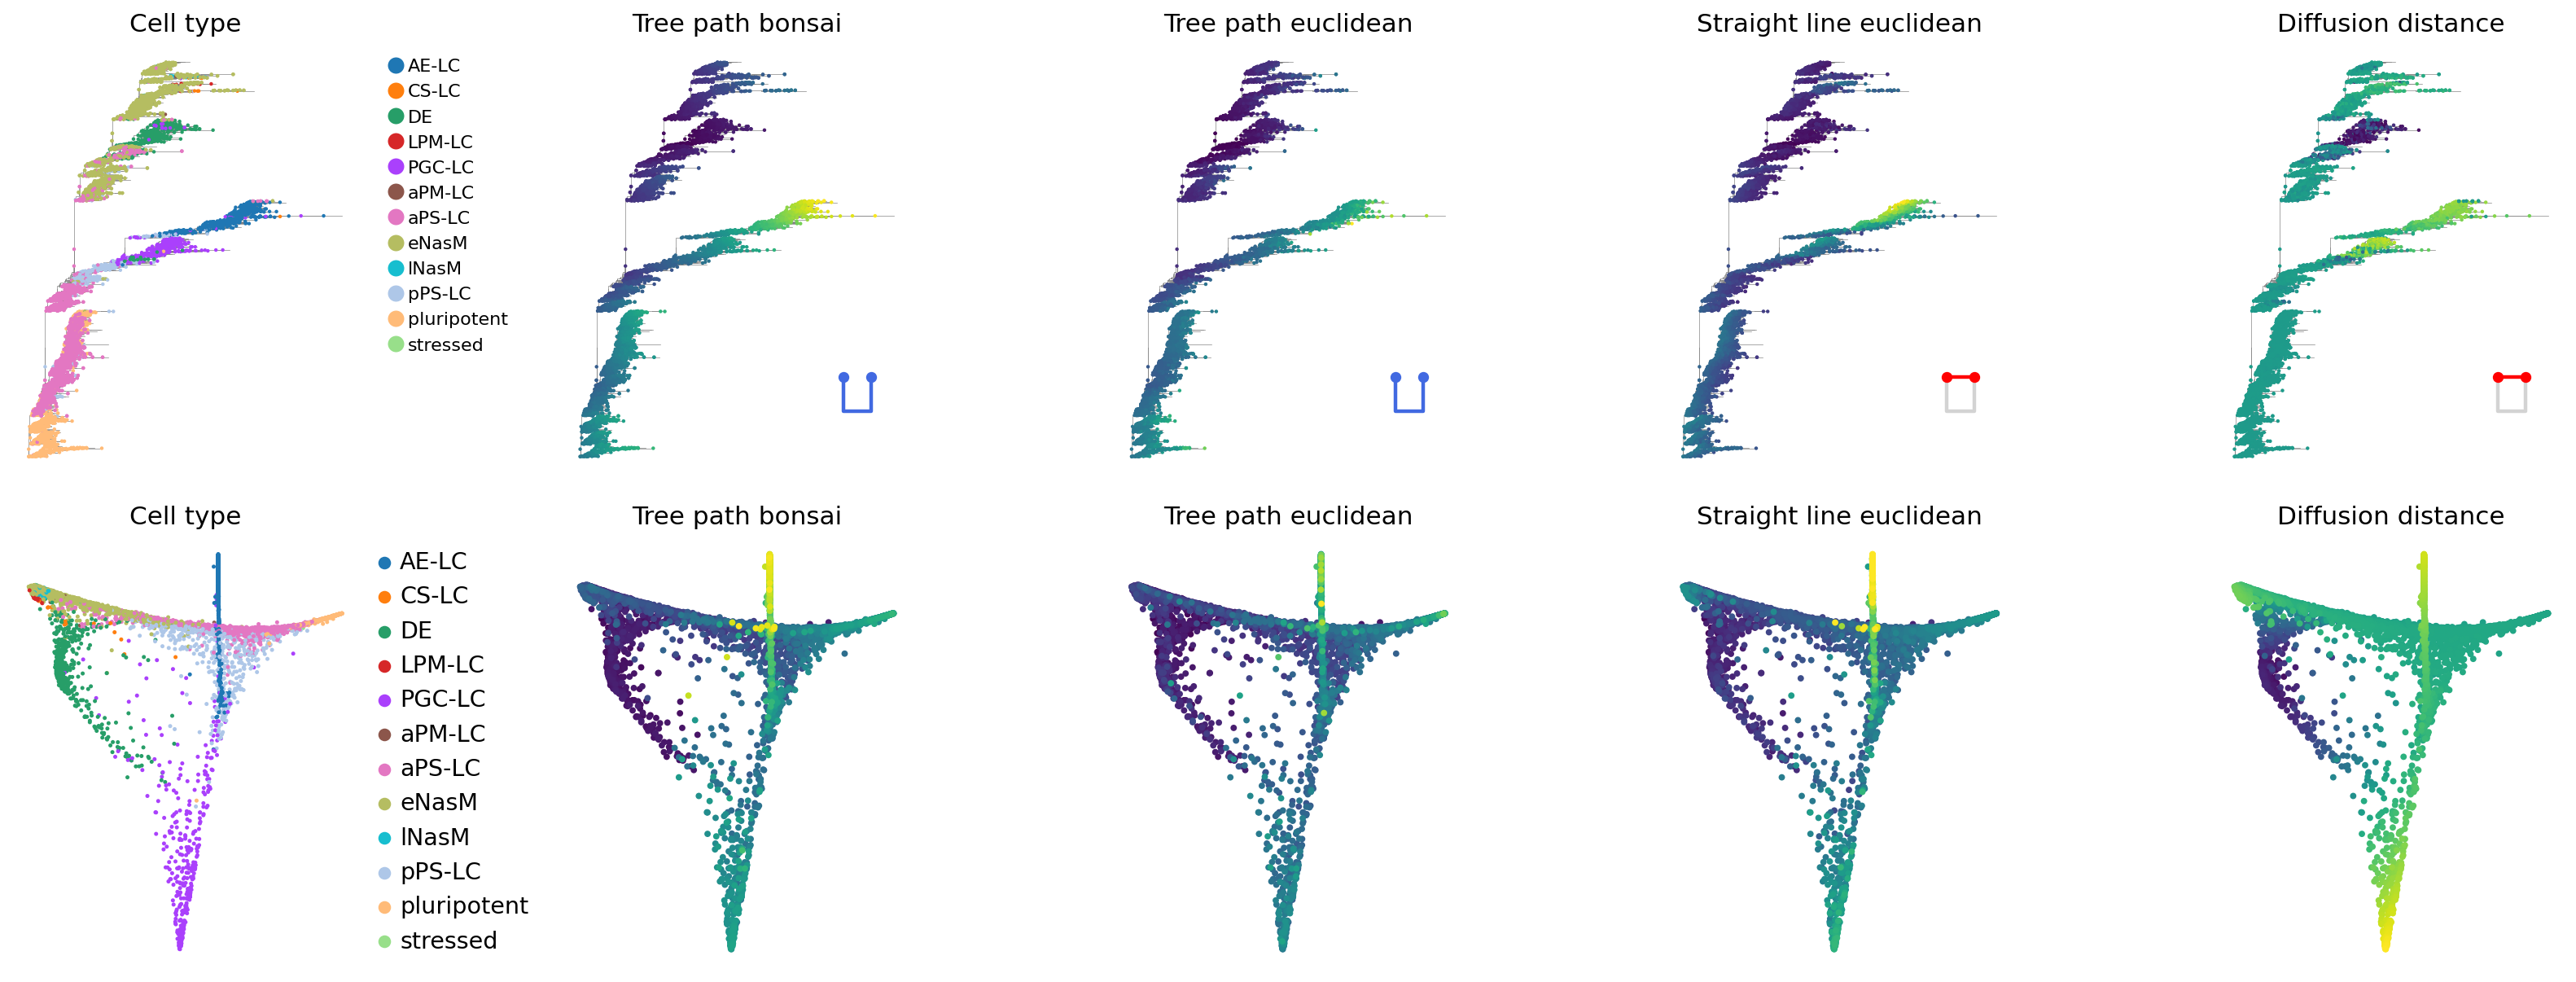

In [ ]:
# dendrogram
fig, axeses = plt.subplots(2, 5, figsize=(20, 8))
vmin, vmax = 0, 15
pointsize = 1

axes = axeses[0, :]
# Left: cell type
for e in edge_coords_d:
    axes[0].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[0].scatter(
    cell_coords_d[:, 0], cell_coords_d[:, 1], s=pointsize, c=cell_colors, zorder=3
)
axes[0].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    s=pointsize,
    c=cell_colors[highlight_cells],
    zorder=5,
)
axes[0].legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
)
axes[0].axis("off")
axes[0].set_title("Cell type")

for e in edge_coords_d:
    axes[1].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[1].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_tree_t,
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[1].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_tree_t_highlighted,
    zorder=5,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[1].set_title("Tree path bonsai")
axes[1].grid(False)
axes[1].axis("off")
# plt.colorbar(axes[1].collections[0], ax=axes[1], label="Distance")

for e in edge_coords_d:
    axes[2].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[2].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_tree_e,
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[2].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_tree_e_highlighted,
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[2].set_title("Tree path euclidean")
axes[2].grid(False)
axes[2].axis("off")
# plt.colorbar(axes[2].collections[0], ax=axes[2], label="Distance")

for e in edge_coords_d:
    axes[3].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[3].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_straight,
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.75),
)
axes[3].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_straight_highlighted,
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.75, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[3].set_title("Straight line euclidean")
axes[3].grid(False)
axes[3].axis("off")
# plt.colorbar(axes[3].collections[0], ax=axes[3], label="Distance")

vmin_diffmap, vmax_diffmap = 0, 1.0
for e in edge_coords_d:
    axes[4].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[4].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_diffmap,
    zorder=3,
    vmin=vmin_diffmap,
    vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_diffmap_highlighted,
    zorder=5,
    s=pointsize,
    vmin=sct.norm.vmin,
    vmax=sct.norm.vmax,
)
axes[4].set_title("Diffusion distance")
axes[4].grid(False)
axes[4].axis("off")
# plt.colorbar(axes[4].collections[0], ax=axes[4], label="Distance")


# axes[0] is cell type — no icon needed
draw_distance_icon(axes[1], kind="tree")  # Tree path bonsai
draw_distance_icon(axes[2], kind="tree")  # Tree path euclidean
draw_distance_icon(axes[3], kind="straight")  # Straight line euclidean
draw_distance_icon(axes[4], kind="straight")  # Diffusion distance

axes = axeses[1, :]
sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["leiden_sub"],
    components=["3,4"],
    ax=axes[0],
    show=False,
    frameon=False,
)
axes[0].set_title("Cell type")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_tree_t"],
    components=["3,4"],
    ax=axes[1],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5),
    s=50,
)
axes[1].set_title("Tree path bonsai")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_tree_e"],
    components=["3,4"],
    ax=axes[2],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5),
    s=50,
)
axes[2].set_title("Tree path euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_straight"],
    components=["3,4"],
    ax=axes[3],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5, vmax=18),
    s=50,
)
axes[3].set_title("Straight line euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_diffmap"],
    components=["3,4"],
    ax=axes[4],
    frameon=False,
    show=False,
    colorbar_loc=None,
    s=50,
)
axes[4].set_title("Diffusion distance")

plt.tight_layout()
plt.savefig("bonsai_hvg_full_data_distances.png", dpi=300)
plt.show()

/tmp/ipykernel_117772/4165649640.py:163: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c=adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"][loop_idx],


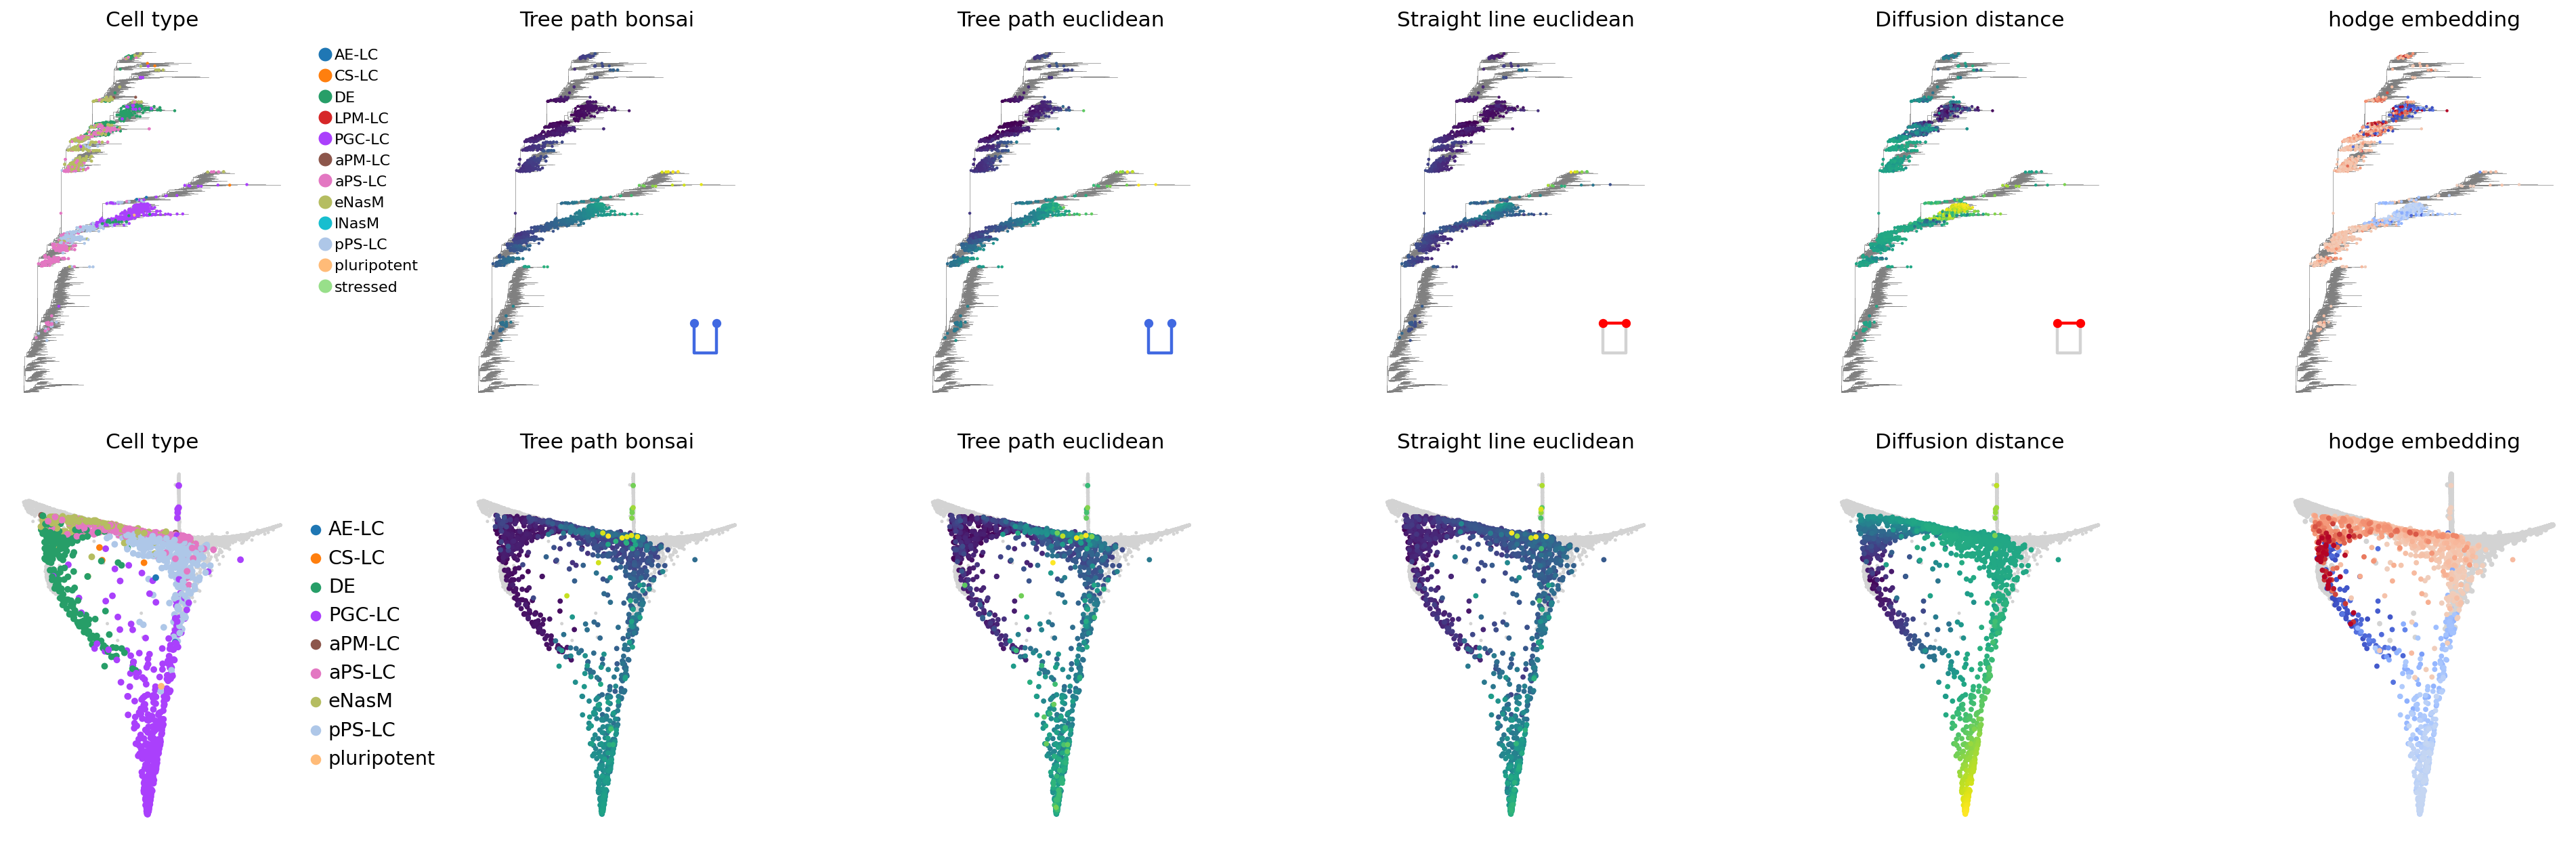

In [25]:
loop_mask = adata.obs["in_loop_knn"] == "PGC-DE"
loop_idx = np.where(loop_mask)[0]
highlight_cells_white_list = np.concatenate(
    [
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "DE",
                adata.obs["bonsai_cluster"].str.contains("cl_2|cl_0|cl_4"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "PGC-LC",
                adata.obs["bonsai_cluster"].str.contains("cl_3|cl_5"),
            )
        )[0],
    ]
)
highlight_cells_loop = np.intersect1d(np.where(loop_mask)[0], highlight_cells)
highlight_cells_loop = np.union1d(highlight_cells_loop, highlight_cells_white_list)
highlight_cells_loop_idx = [
    np.where(i == highlight_cells)[0][0] for i in highlight_cells_loop
]
vmin, vmax = 0, 15
pointsize = 1
fig, axeses = plt.subplots(2, 6, figsize=(24, 8))

axes = axeses[0, :]
# Left: cell type
for e in edge_coords_d:
    axes[0].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[0].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    s=pointsize,
    c=cell_colors[loop_idx],
    zorder=3,
)
axes[0].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    s=pointsize,
    c=cell_colors[highlight_cells_loop],
    zorder=5,
)
axes[0].legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
)
axes[0].axis("off")
axes[0].set_title("Cell type")

for e in edge_coords_d:
    axes[1].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[1].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_tree_t[loop_idx],
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[1].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_tree_t_highlighted[highlight_cells_loop_idx],
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[1].set_title("Tree path bonsai")
axes[1].grid(False)
axes[1].axis("off")
# plt.colorbar(axes[1].collections[0], ax=axes[1], label="Distance")

for e in edge_coords_d:
    axes[2].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[2].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_tree_e[loop_idx],
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[2].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_tree_e_highlighted[highlight_cells_loop_idx],
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[2].set_title("Tree path euclidean")
axes[2].grid(False)
axes[2].axis("off")
# plt.colorbar(axes[2].collections[0], ax=axes[2], label="Distance")

for e in edge_coords_d:
    axes[3].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[3].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_straight[loop_idx],
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.75),
)
axes[3].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_straight_highlighted[highlight_cells_loop_idx],
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.75, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[3].set_title("Straight line euclidean")
axes[3].grid(False)
axes[3].axis("off")
# plt.colorbar(axes[3].collections[0], ax=axes[3], label="Distance")

vmin_diffmap, vmax_diffmap = 0, 1.0
for e in edge_coords_d:
    axes[4].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[4].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_diffmap[loop_idx],
    zorder=3,
    # vmin=vmin_diffmap,
    # vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_diffmap_highlighted[highlight_cells_loop_idx],
    zorder=5,
    vmin=sct.norm.vmin,
    vmax=sct.norm.vmax,
    # vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].set_title("Diffusion distance")
axes[4].grid(False)
axes[4].axis("off")

for e in edge_coords_d:
    axes[5].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[5].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    s=pointsize,
    c=adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"][loop_idx],
    zorder=3,
    cmap="coolwarm",
)
axes[5].set_title("hodge embedding")
axes[5].grid(False)
axes[5].axis("off")
# plt.colorbar(axes[4].collections[0], ax=axes[4], label="Distance")

# axes[0] is cell type — no icon needed
draw_distance_icon(axes[1], kind="tree")  # Tree path bonsai
draw_distance_icon(axes[2], kind="tree")  # Tree path euclidean
draw_distance_icon(axes[3], kind="straight")  # Straight line euclidean
draw_distance_icon(axes[4], kind="straight")  # Diffusion distance

axes = axeses[1, :]
sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[0],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["leiden_sub"],
    components=["3,4"],
    ax=axes[0],
    show=False,
    frameon=False,
)
axes[0].set_title("Cell type")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[1],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_tree_t"],
    components=["3,4"],
    ax=axes[1],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5),
    s=50,
)
axes[1].set_title("Tree path bonsai")


sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[2],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_tree_e"],
    components=["3,4"],
    ax=axes[2],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5),
    s=50,
)
axes[2].set_title("Tree path euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[3],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_straight"],
    components=["3,4"],
    ax=axes[3],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5, vmax=18),
    s=50,
)
axes[3].set_title("Straight line euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[4],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_diffmap"],
    components=["3,4"],
    ax=axes[4],
    frameon=False,
    show=False,
    colorbar_loc=None,
    s=50,
)
axes[4].set_title("Diffusion distance")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["PGC-DE_hodge_knn_smooth_sep_lin"],
    components=["3,4"],
    ax=axes[5],
    show=False,
    frameon=False,
    colorbar_loc=None,
    s=50,
    cmap="coolwarm",
)
axes[5].set_title("hodge embedding")
axes[5].grid(False)
axes[5].axis("off")
plt.tight_layout()
plt.savefig("bonsai_hvg_loop_data_distances.png", dpi=300)
plt.show()

# full gene output

In [26]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords
f.close()

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

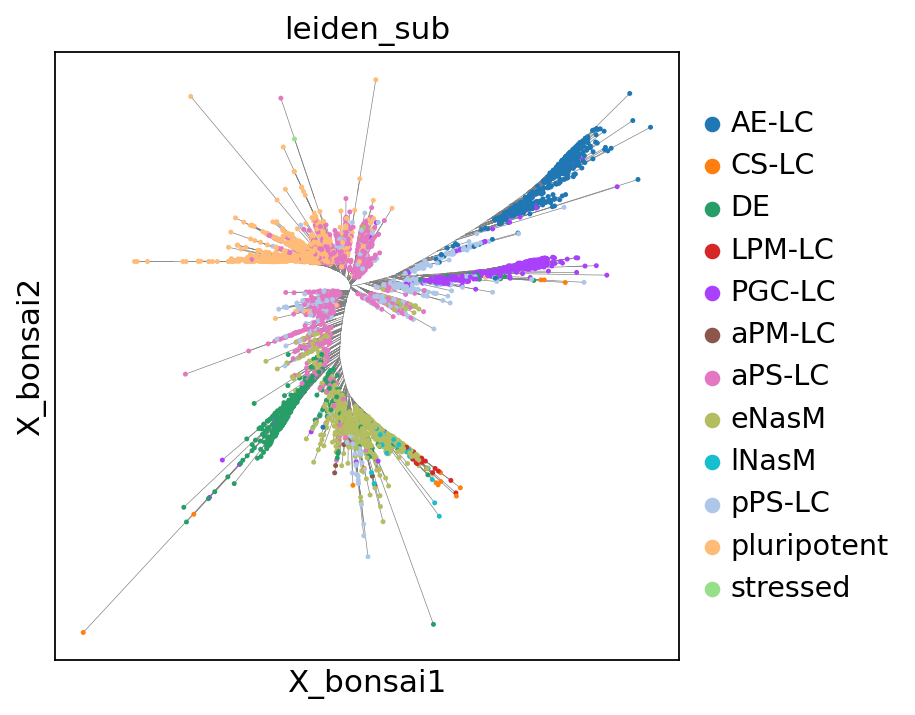

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

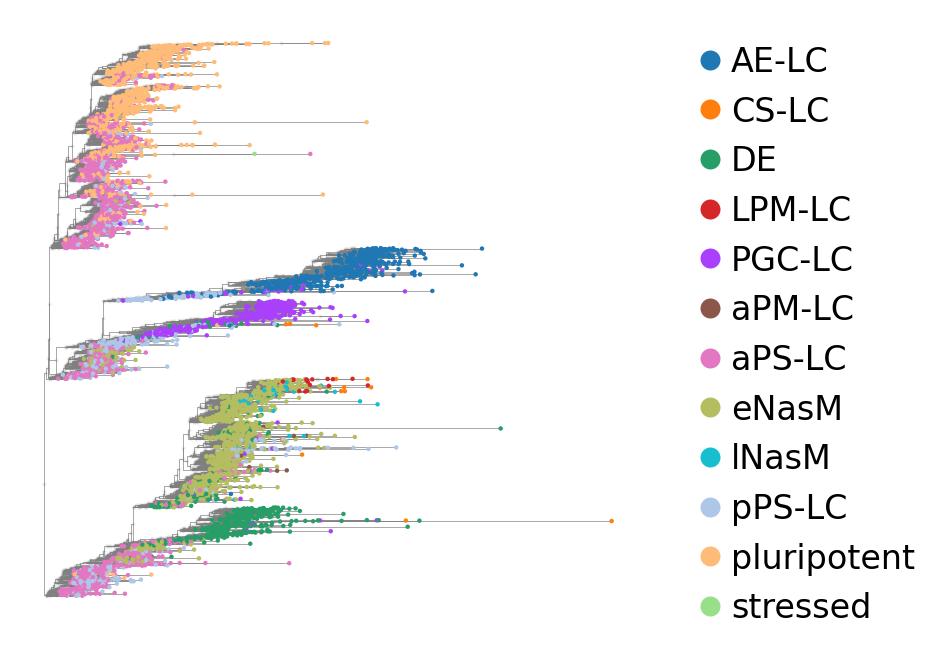

In [28]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
f.close()

In [29]:
from my_tree_layout import Layout_Tree

node_id_to_vert_ind = {}
with open("./heemskerk_data/Bonsai_48h-1/final_bonsai/vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai/tree.nwk") as f:
    nwk_str = f.read().strip()

ly_tree = Layout_Tree()
ly_tree.from_newick(nwk_str, node_id_to_vert_ind=node_id_to_vert_ind)
ly_tree.reset_root(node_id_to_vert_ind["internal_4393"])
ly_tree.equalAngle()
coords = ly_tree.coords.copy()

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

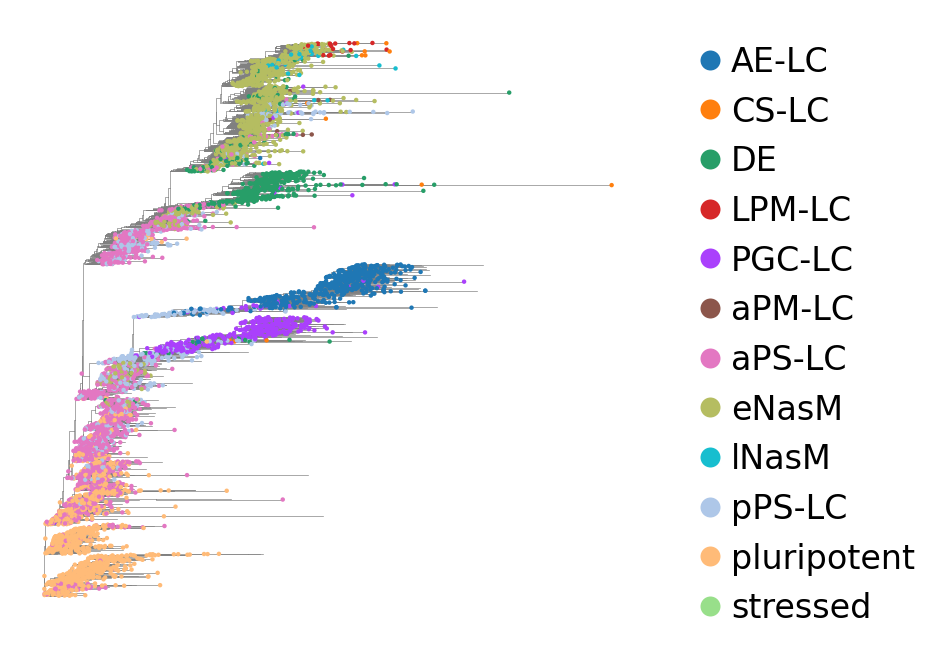

In [30]:
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [31]:
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")

from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

annotation_dict = adata.obs["leiden_sub"].to_dict()

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai/tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

03-30 06:46:19 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5367414141588863.
03-30 06:46:19 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.5970256128646635.
03-30 06:46:19 mp_print INFO 
After making 6 clusters, norm. mutual information doesn't significantly increase. Stopping here.
03-30 06:46:19 mp_print INFO Final annotation-based clustering did 6 moves, created 6 clusters, with a Normalized Mutual Information of 0.6091296326484865.
03-30 06:46:19 mp_print INFO Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

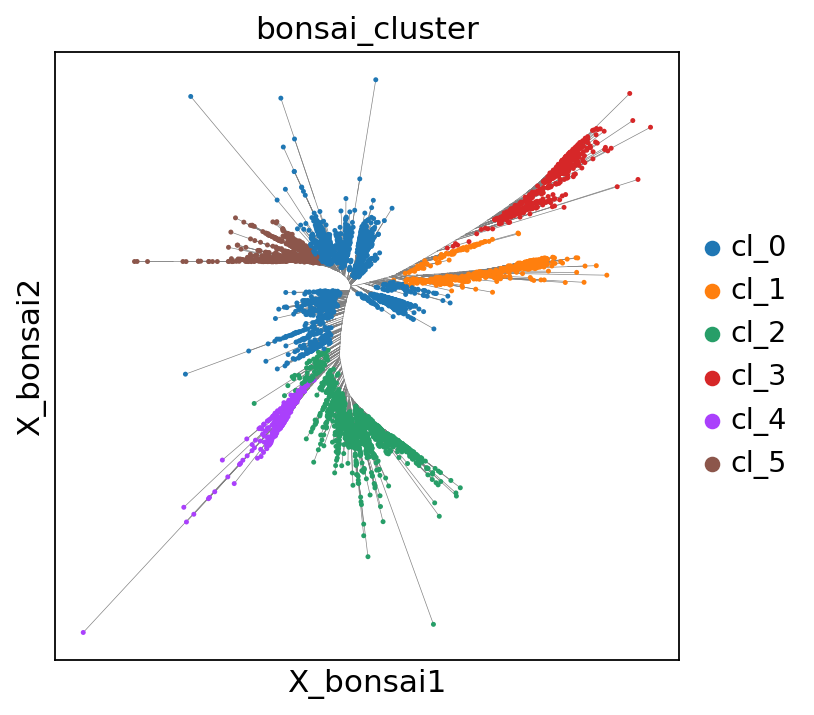

In [32]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

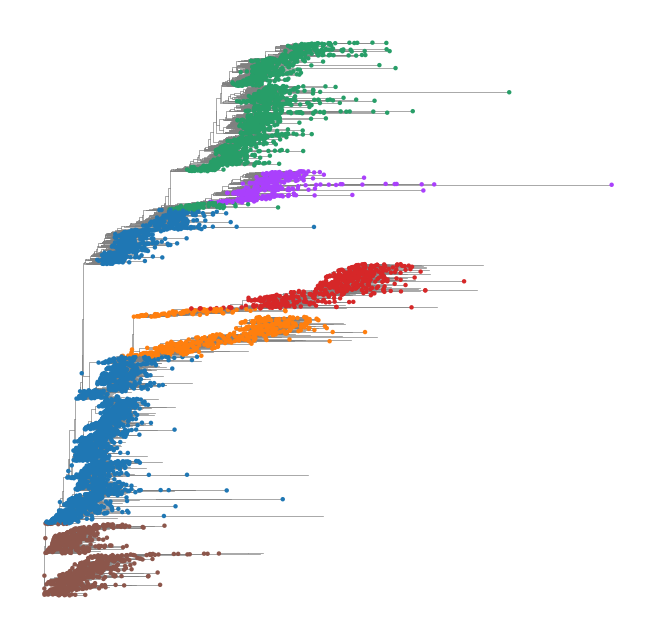

In [33]:
colors = adata.uns["bonsai_cluster_colors"]
categories = adata.obs["bonsai_cluster"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["bonsai_cluster"].map(cat_to_color).values

ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

2574


(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

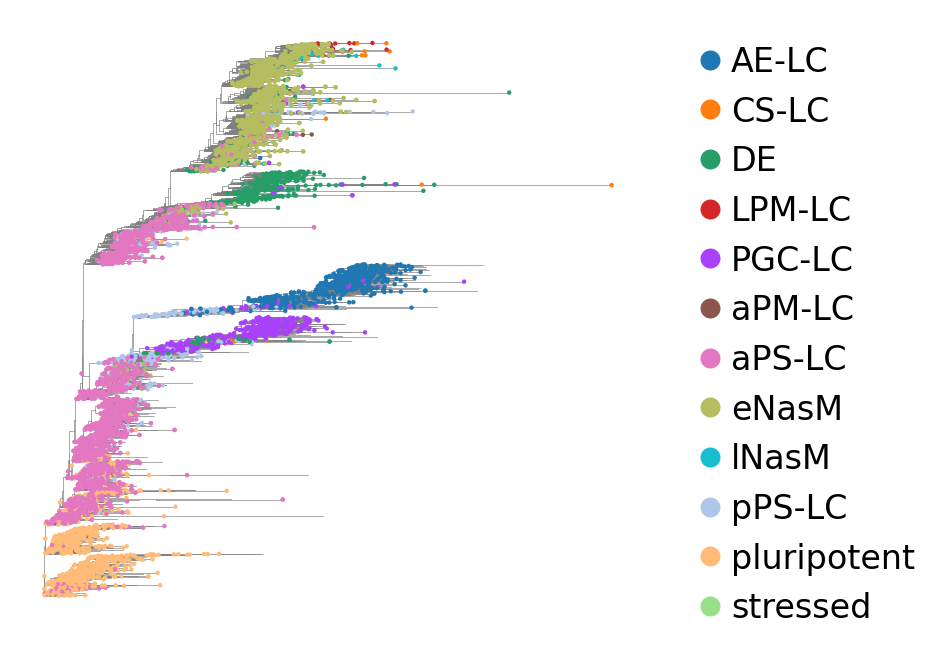

In [34]:
highlight_cells = np.concatenate(
    [
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "DE",
                adata.obs["bonsai_cluster"].str.contains("cl_1|cl_3"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "PGC-LC",
                adata.obs["bonsai_cluster"].str.contains("cl_4|cl_2"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("eNasM|aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_2"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_0"),
            )
        )[0],
    ]
)
print(len(highlight_cells))

colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()
np.random.seed(1)
reorder_ind = np.random.permutation(cell_coords_d.shape[0])

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    cell_coords_d[reorder_ind, 0],
    cell_coords_d[reorder_ind, 1],
    s=1,
    c=cell_colors[reorder_ind],
    zorder=3,
)
ax.scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    s=1,
    c=cell_colors[highlight_cells],
    zorder=5,
)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [ ]:
# distances
import networkx as nx

bonsai_dir = "./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai"
ltq_coords = np.load(f"{bonsai_dir}/posterior_ltqs_vertByGene.npy")
ltq_var_coords = np.load(f"{bonsai_dir}/posterior_ltqsVars_vertByGene.npy")
source_vert = node_id_to_vert_ind["GTGCTGGTCGGTATGT-1_48h"]
std_factor = 2
G = nx.Graph()
with open(f"{bonsai_dir}/edgeInfo.txt") as f:
    for line in f:
        v1, v2, d = line.strip().split("\t")
        v1, v2 = int(v1), int(v2)
        std_child = np.sqrt(ltq_var_coords[v2])
        eucli_d = np.maximum(
            np.abs(ltq_coords[v1] - ltq_coords[v2]) - std_factor * std_child, 0.0
        )
        eucli = float(np.linalg.norm(eucli_d))
        G.add_edge(v1, v2, weight=np.sqrt(float(d)), weight_euclidean=eucli)

# straightline distance
straight_dist_scale = 0.3
dist_to_source_straightline = (
    np.linalg.norm(
        np.maximum(
            np.abs(ltq_coords - ltq_coords[source_vert]) - std_factor * ltq_var_coords,
            0,
        ),
        axis=1,
    )
    * straight_dist_scale
)

In [36]:
# recompute diffmap
if "X_diffmap" in adata.obsm:
    del adata.obsm["X_diffmap"]
adata.obsm["X_ltq"] = np.array(
    pd.read_csv(
        "./heemskerk_data/sanity_hvg/log_transcription_quotients_vmax.txt",
        sep="\t",
        index_col=0,
    )
).T
sc.pp.neighbors(adata, use_rep="X_ltq", n_neighbors=25, method="gauss")
sc.tl.diffmap(adata)
# diffusion distance
source_diffmap = adata["GTGCTGGTCGGTATGT-1_48h"].obsm["X_diffmap_original"][:, :]
cell_diffmap = adata[cell_ids].obsm["X_diffmap_original"][:, :]
cell_diffmap_dists = np.linalg.norm(cell_diffmap - source_diffmap, axis=1)

# Shortest path distances (= tree path distances since it's a tree)
source_vert = node_id_to_vert_ind["GTGCTGGTCGGTATGT-1_48h"]
bonsai_tree_t_dists = nx.shortest_path_length(G, source=source_vert, weight="weight")
bonsai_tree_e_dists = nx.shortest_path_length(
    G, source=source_vert, weight="weight_euclidean"
)

In [37]:
cell_dists_tree_t = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = bonsai_tree_t_dists.get(vert_idx, np.nan)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_tree_t[ci] = d
    else:
        cell_dists_tree_t[cell_idx] = d

cell_dists_tree_e = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = bonsai_tree_e_dists.get(vert_idx, np.nan)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_tree_e[ci] = d

cell_dists_straight = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = dist_to_source_straightline[vert_idx]
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_straight[ci] = d

cell_dists_diffmap = np.zeros(len(cell_ids))
for _, cell_idx in vert_to_cell.items():
    d = cell_diffmap_dists[cell_idx] if cell_idx else np.nan
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_diffmap[ci] = d[0]
    else:
        cell_dists_diffmap[cell_idx] = d


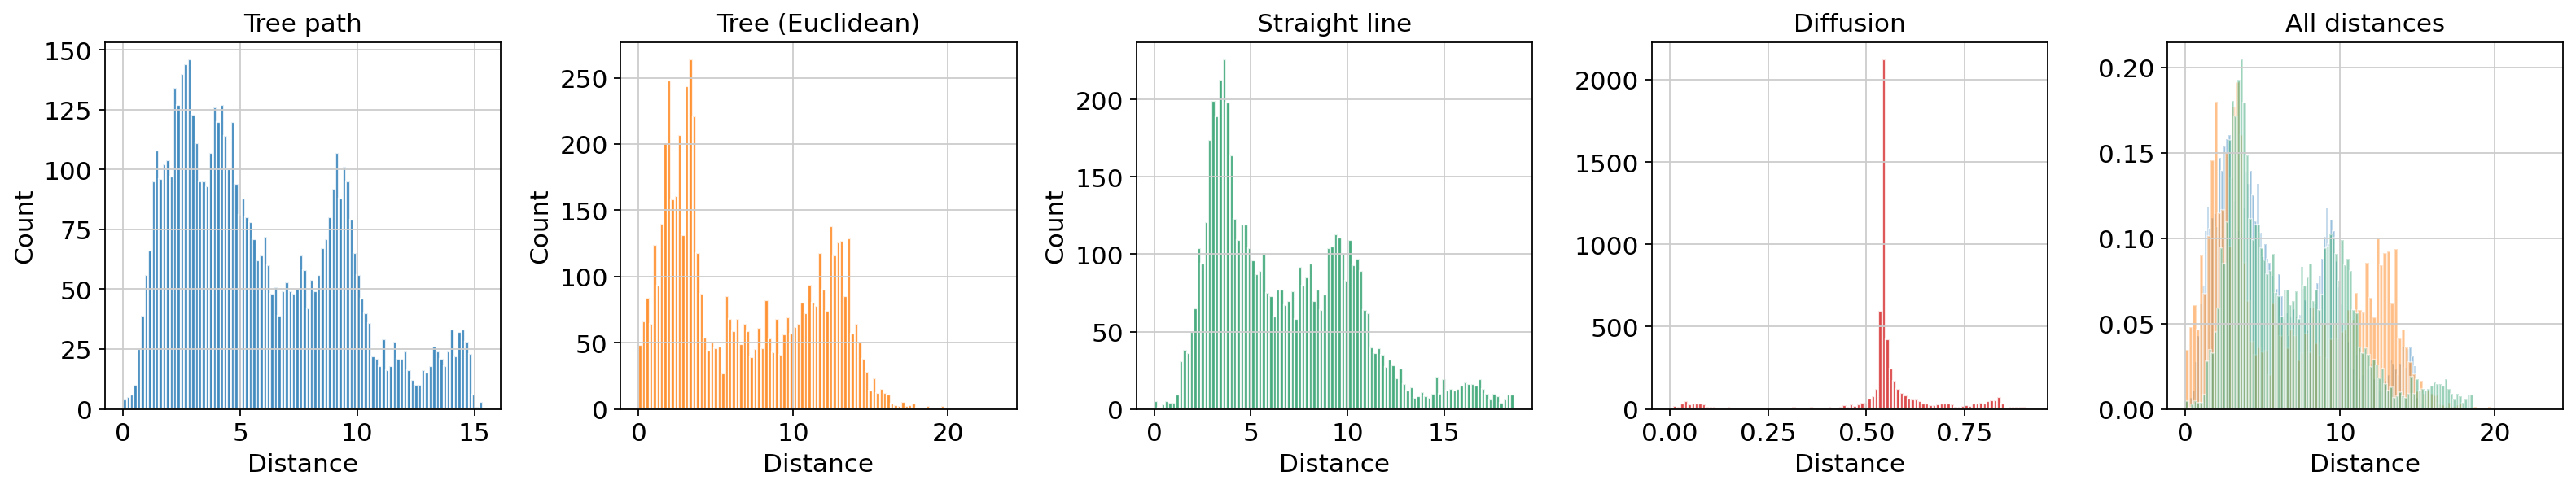

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].hist(cell_dists_tree_t, bins=100, color="C0", alpha=0.85, edgecolor="white")
axes[0].set_title("Tree path")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")

axes[1].hist(cell_dists_tree_e, bins=100, color="C1", alpha=0.85, edgecolor="white")
axes[1].set_title("Tree (Euclidean)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")

axes[2].hist(cell_dists_straight, bins=100, color="C2", alpha=0.85, edgecolor="white")
axes[2].set_title("Straight line")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")

axes[3].hist(cell_dists_diffmap, bins=100, color="C3", alpha=0.85, edgecolor="white")
axes[3].set_title("Diffusion")
axes[3].set_xlabel("Distance")

axes[4].hist(
    cell_dists_tree_t, bins=100, color="C0", alpha=0.5, edgecolor="white", density=True
)
axes[4].hist(
    cell_dists_tree_e, bins=100, color="C1", alpha=0.5, edgecolor="white", density=True
)
axes[4].hist(
    cell_dists_straight,
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[4].set_title("All distances")
axes[4].set_xlabel("Distance")

plt.tight_layout()
plt.show()

In [39]:
cell_dists_tree_t_highlighted = cell_dists_tree_t[highlight_cells]
cell_dists_tree_e_highlighted = cell_dists_tree_e[highlight_cells]
cell_dists_straight_highlighted = cell_dists_straight[highlight_cells]
cell_dists_diffmap_highlighted = cell_dists_diffmap[highlight_cells]

In [40]:
adata.obs["cell_dists_tree_t"] = cell_dists_tree_t
adata.obs["cell_dists_tree_e"] = cell_dists_tree_e
adata.obs["cell_dists_straight"] = cell_dists_straight
adata.obs["cell_dists_diffmap"] = cell_dists_diffmap

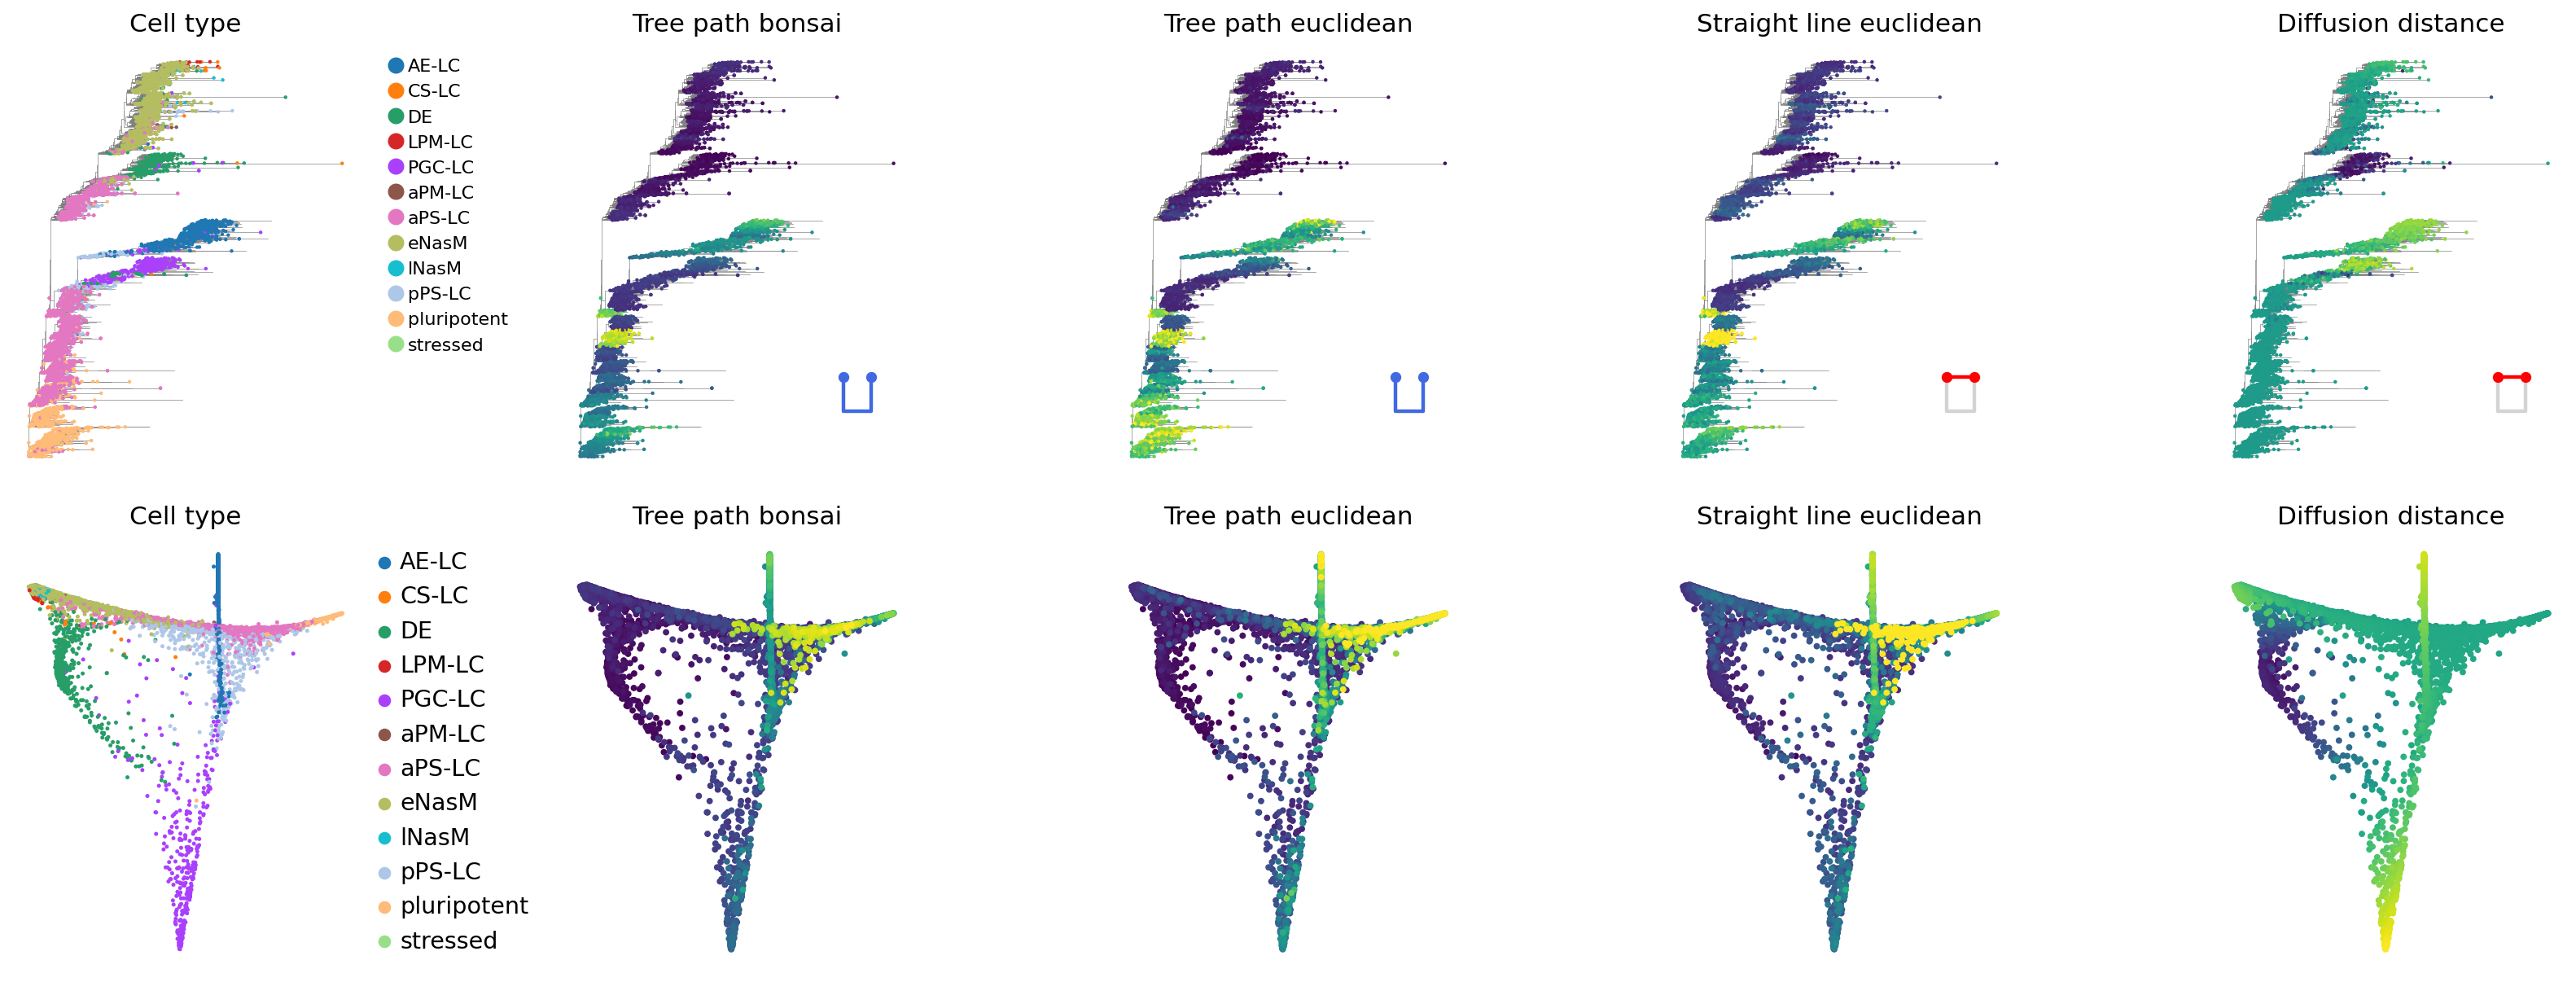

In [41]:
from matplotlib.colors import PowerNorm

# dendrogram
fig, axeses = plt.subplots(2, 5, figsize=(20, 8))
vmin, vmax = 0, 15
pointsize = 1

axes = axeses[0, :]
# Left: cell type
for e in edge_coords_d:
    axes[0].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[0].scatter(
    cell_coords_d[:, 0], cell_coords_d[:, 1], s=pointsize, c=cell_colors, zorder=3
)
axes[0].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    s=pointsize,
    c=cell_colors[highlight_cells],
    zorder=5,
)
axes[0].legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
)
axes[0].axis("off")
axes[0].set_title("Cell type")

for e in edge_coords_d:
    axes[1].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[1].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_tree_t,
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[1].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_tree_t_highlighted,
    zorder=5,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[1].set_title("Tree path bonsai")
axes[1].grid(False)
axes[1].axis("off")
# plt.colorbar(axes[1].collections[0], ax=axes[1], label="Distance")

for e in edge_coords_d:
    axes[2].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[2].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_tree_e,
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmax=vmax),
)
axes[2].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_tree_e_highlighted,
    zorder=5,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[2].set_title("Tree path euclidean")
axes[2].grid(False)
axes[2].axis("off")
# plt.colorbar(axes[2].collections[0], ax=axes[2], label="Distance")

for e in edge_coords_d:
    axes[3].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[3].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_straight,
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.25, vmax=vmax),
)
axes[3].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_straight_highlighted,
    zorder=5,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.25, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[3].set_title("Straight line euclidean")
axes[3].grid(False)
axes[3].axis("off")
# plt.colorbar(axes[3].collections[0], ax=axes[3], label="Distance")

vmin_diffmap, vmax_diffmap = 0, 1.0
for e in edge_coords_d:
    axes[4].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[4].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    c=cell_dists_diffmap,
    zorder=3,
    vmin=vmin_diffmap,
    vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    c=cell_dists_diffmap_highlighted,
    zorder=5,
    vmin=vmin_diffmap,
    vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].set_title("Diffusion distance")
axes[4].grid(False)
axes[4].axis("off")
# plt.colorbar(axes[4].collections[0], ax=axes[4], label="Distance")

# axes[0] is cell type — no icon needed
draw_distance_icon(axes[1], kind="tree")  # Tree path bonsai
draw_distance_icon(axes[2], kind="tree")  # Tree path euclidean
draw_distance_icon(axes[3], kind="straight")  # Straight line euclidean
draw_distance_icon(axes[4], kind="straight")  # Diffusion distance

axes = axeses[1, :]
sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["leiden_sub"],
    components=["3,4"],
    ax=axes[0],
    show=False,
    frameon=False,
)
axes[0].set_title("Cell type")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_tree_t"],
    components=["3,4"],
    ax=axes[1],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5),
    s=50,
)
axes[1].set_title("Tree path bonsai")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_tree_e"],
    components=["3,4"],
    ax=axes[2],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5, vmax=vmax),
    s=50,
)
axes[2].set_title("Tree path euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_straight"],
    components=["3,4"],
    ax=axes[3],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.25, vmax=vmax),
    s=50,
)
axes[3].set_title("Straight line euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["cell_dists_diffmap"],
    components=["3,4"],
    ax=axes[4],
    frameon=False,
    show=False,
    colorbar_loc=None,
    s=50,
)
axes[4].set_title("Diffusion distance")

plt.tight_layout()
plt.savefig("bonsai_raw_full_data_distances.png", dpi=300)
plt.show()

/tmp/ipykernel_117772/1342424402.py:163: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c=adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"][loop_idx],


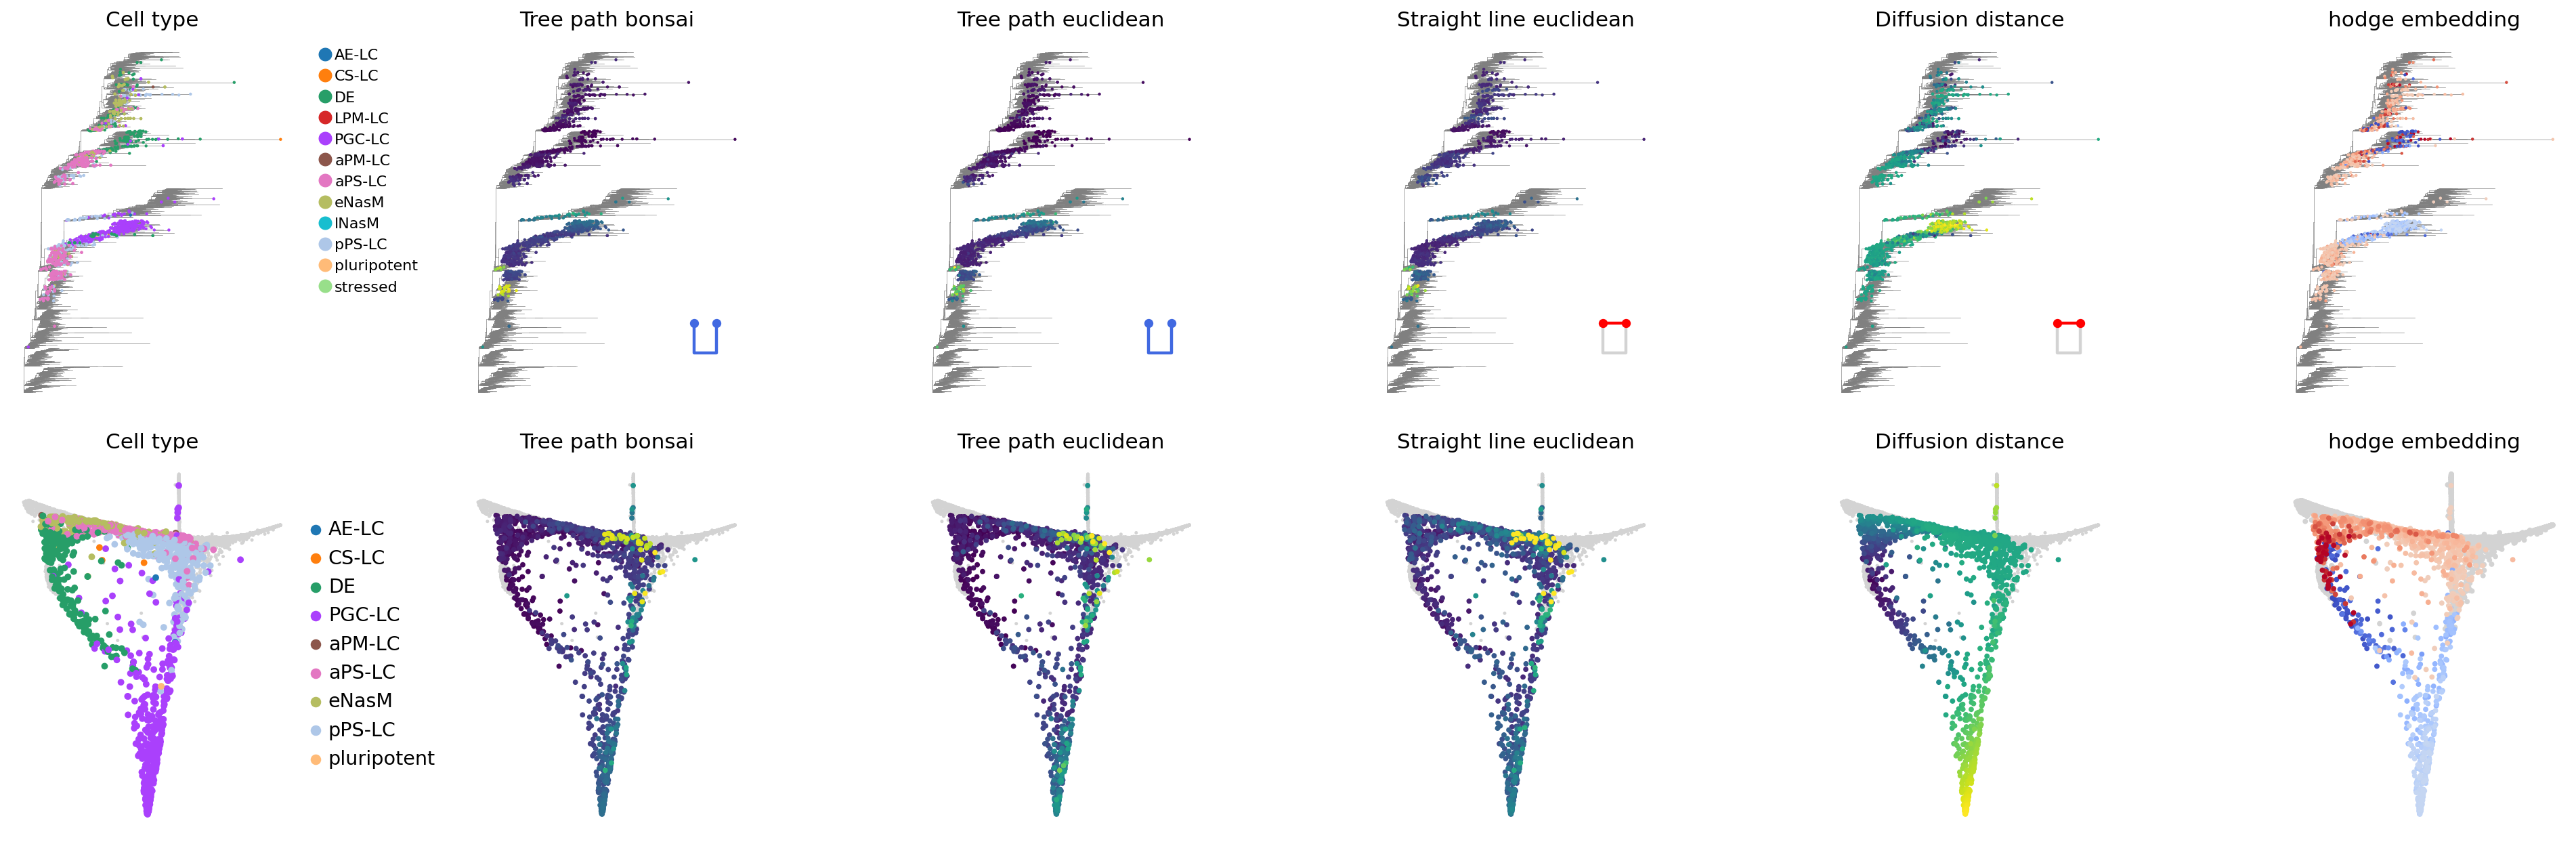

In [42]:
loop_mask = adata.obs["in_loop_knn"] == "PGC-DE"
loop_idx = np.where(loop_mask)[0]
highlight_cells_white_list = np.concatenate(
    [
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "DE",
                adata.obs["bonsai_cluster"].str.contains("cl_1|cl_3"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "PGC-LC",
                adata.obs["bonsai_cluster"].str.contains("cl_4|cl_2"),
            )
        )[0],
    ]
)
highlight_cells_loop = np.intersect1d(np.where(loop_mask)[0], highlight_cells)
highlight_cells_loop = np.union1d(highlight_cells_loop, highlight_cells_white_list)
highlight_cells_loop_idx = [
    np.where(i == highlight_cells)[0][0] for i in highlight_cells_loop
]
vmin, vmax = 0, 15
pointsize = 1
fig, axeses = plt.subplots(2, 6, figsize=(24, 8))

axes = axeses[0, :]
# Left: cell type
for e in edge_coords_d:
    axes[0].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[0].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    s=pointsize,
    c=cell_colors[loop_idx],
    zorder=3,
)
axes[0].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    s=pointsize,
    c=cell_colors[highlight_cells_loop],
    zorder=5,
)
axes[0].legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
)
axes[0].axis("off")
axes[0].set_title("Cell type")

for e in edge_coords_d:
    axes[1].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[1].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_tree_t[loop_idx],
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[1].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_tree_t_highlighted[highlight_cells_loop_idx],
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[1].set_title("Tree path bonsai")
axes[1].grid(False)
axes[1].axis("off")
# plt.colorbar(axes[1].collections[0], ax=axes[1], label="Distance")

for e in edge_coords_d:
    axes[2].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[2].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_tree_e[loop_idx],
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.5),
)
axes[2].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_tree_e_highlighted[highlight_cells_loop_idx],
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.5, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[2].set_title("Tree path euclidean")
axes[2].grid(False)
axes[2].axis("off")
# plt.colorbar(axes[2].collections[0], ax=axes[2], label="Distance")

for e in edge_coords_d:
    axes[3].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[3].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_straight[loop_idx],
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
    s=pointsize,
    norm=PowerNorm(gamma=1.25),
)
axes[3].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_straight_highlighted[highlight_cells_loop_idx],
    zorder=5,
    s=pointsize,
    norm=PowerNorm(gamma=1.25, vmin=sct.norm.vmin, vmax=sct.norm.vmax),
)
axes[3].set_title("Straight line euclidean")
axes[3].grid(False)
axes[3].axis("off")
# plt.colorbar(axes[3].collections[0], ax=axes[3], label="Distance")

vmin_diffmap, vmax_diffmap = 0, 1.0
for e in edge_coords_d:
    axes[4].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sct = axes[4].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    c=cell_dists_diffmap[loop_idx],
    zorder=3,
    # vmin=vmin_diffmap,
    # vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].scatter(
    cell_coords_d[highlight_cells_loop, 0],
    cell_coords_d[highlight_cells_loop, 1],
    c=cell_dists_diffmap_highlighted[highlight_cells_loop_idx],
    zorder=5,
    vmin=sct.norm.vmin,
    vmax=sct.norm.vmax,
    # vmax=vmax_diffmap,
    s=pointsize,
)
axes[4].set_title("Diffusion distance")
axes[4].grid(False)
axes[4].axis("off")

for e in edge_coords_d:
    axes[5].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[5].scatter(
    cell_coords_d[loop_idx, 0],
    cell_coords_d[loop_idx, 1],
    s=pointsize,
    c=adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"][loop_idx],
    zorder=3,
    cmap="coolwarm",
)
axes[5].set_title("hodge embedding")
axes[5].grid(False)
axes[5].axis("off")
# plt.colorbar(axes[4].collections[0], ax=axes[4], label="Distance")

# axes[0] is cell type — no icon needed
draw_distance_icon(axes[1], kind="tree")  # Tree path bonsai
draw_distance_icon(axes[2], kind="tree")  # Tree path euclidean
draw_distance_icon(axes[3], kind="straight")  # Straight line euclidean
draw_distance_icon(axes[4], kind="straight")  # Diffusion distance

axes = axeses[1, :]
sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[0],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["leiden_sub"],
    components=["3,4"],
    ax=axes[0],
    show=False,
    frameon=False,
)
axes[0].set_title("Cell type")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[1],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_tree_t"],
    components=["3,4"],
    ax=axes[1],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5),
    s=50,
)
axes[1].set_title("Tree path bonsai")


sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[2],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_tree_e"],
    components=["3,4"],
    ax=axes[2],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.5, vmax=vmax),
    s=50,
)
axes[2].set_title("Tree path euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[3],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_straight"],
    components=["3,4"],
    ax=axes[3],
    show=False,
    frameon=False,
    colorbar_loc=None,
    norm=PowerNorm(gamma=1.25, vmax=vmax),
    s=50,
)
axes[3].set_title("Straight line euclidean")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    components=["3,4"],
    ax=axes[4],
    show=False,
    frameon=False,
)
sc.pl.embedding(
    adata[loop_idx],
    basis="X_diffmap_original",
    color=["cell_dists_diffmap"],
    components=["3,4"],
    ax=axes[4],
    frameon=False,
    show=False,
    colorbar_loc=None,
    s=50,
)
axes[4].set_title("Diffusion distance")

sc.pl.embedding(
    adata,
    basis="X_diffmap_original",
    color=["PGC-DE_hodge_knn_smooth_sep_lin"],
    components=["3,4"],
    ax=axes[5],
    show=False,
    frameon=False,
    colorbar_loc=None,
    s=50,
    cmap="coolwarm",
)
axes[5].set_title("hodge embedding")
axes[5].grid(False)
axes[5].axis("off")
plt.tight_layout()
plt.savefig("bonsai_raw_loop_data_distances.png", dpi=300)
plt.show()